# Data Preparation — Edible Wild Plants
> Downloads the Kaggle dataset and creates an 80/10/10 train/val/test split.
> Run this notebook **once** before training any model.

In [ ]:
!pip install kagglehub -q

import kagglehub, os, gc, random, shutil
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Ready.")

Ready.


In [ ]:
# Mount Google Drive so the split survives Colab restarts
from google.colab import drive
drive.mount('/content/drive')

# Drive directory for models (shared across all training notebooks)
DRIVE_MODEL_DIR = '/content/drive/MyDrive/edible_plants_models'
os.makedirs(DRIVE_MODEL_DIR, exist_ok=True)
print("Drive model dir:", DRIVE_MODEL_DIR)

Mounted at /content/drive
Drive model dir: /content/drive/MyDrive/edible_plants_models


In [ ]:
# Download dataset (~1 GB, cached on subsequent runs)
path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)
print("Top-level contents:", os.listdir(path))

Using Colab cache for faster access to the 'edible-wild-plants' dataset.
Dataset path: /kaggle/input/edible-wild-plants
Top-level contents: ['datasets', 'final_model_weights.hdf5', 'edible wild plants metadata.xls', 'vanilla_model_weights.hdf5']


In [ ]:
# Locate the directory that contains the 62 class sub-folders
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imgs:
                    return root
    return None

SOURCE_DIR = find_class_root(path)

if SOURCE_DIR is None:
    raise RuntimeError("Could not find class root inside dataset path.")

all_classes = sorted([d for d in os.listdir(SOURCE_DIR)
                       if os.path.isdir(os.path.join(SOURCE_DIR, d))])

print(f"SOURCE_DIR : {SOURCE_DIR}")
print(f"Classes    : {len(all_classes)}")
print(f"First 5    : {all_classes[:5]}")

SOURCE_DIR : /kaggle/input/edible-wild-plants/datasets/dataset
Classes    : 62
First 5    : ['Alfalfa', 'Asparagus', 'Blue Vervain', 'Broadleaf Plantain', 'Bull Thistle']


In [ ]:
# Create stratified 80 / 10 / 10 train / val / test split
BASE_DIR  = '/content/plant_data'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

# Always rebuild from scratch to avoid stale data
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)
    print("Removed old split")

def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
    random.seed(seed)
    skipped = []
    counts  = {'train': 0, 'val': 0, 'test': 0}
    for cls in classes:
        src = os.path.join(source, cls)
        if not os.path.isdir(src):
            continue
        imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                and os.path.isfile(os.path.join(src, f))]
        if len(imgs) < 5:          # skip tiny classes
            skipped.append(cls); continue
        random.shuffle(imgs)
        n_tr  = int(len(imgs) * train_r)
        n_val = max(int(len(imgs) * val_r), 1)
        for split, flist in [('train', imgs[:n_tr]),
                               ('val',   imgs[n_tr:n_tr+n_val]),
                               ('test',  imgs[n_tr+n_val:])]:
            dest = os.path.join(base, split, cls)
            os.makedirs(dest, exist_ok=True)
            for f in flist:
                shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
            counts[split] += len(flist)
    return counts, skipped

print("Creating 80/10/10 split …")
counts, skipped = make_split(SOURCE_DIR, BASE_DIR, all_classes)
if skipped:
    print(f"Skipped {len(skipped)} classes (too few images): {skipped}")
print("Split counts:", counts)

Creating 80/10/10 split …
Split counts: {'train': 5246, 'val': 655, 'test': 657}


In [ ]:
# Verify the split
print("\nSplit verification:")
print(f"{'Split':<8} {'Classes':>8} {'Images':>8}")
print("-" * 28)
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    cls_list = [c for c in os.listdir(d) if os.path.isdir(os.path.join(d, c))]
    n_imgs   = sum(len(os.listdir(os.path.join(d, c))) for c in cls_list)
    print(f"{split:<8} {len(cls_list):>8} {n_imgs:>8}")

NUM_CLASSES = len([c for c in os.listdir(TRAIN_DIR)
                   if os.path.isdir(os.path.join(TRAIN_DIR, c))])
print(f"\nNUM_CLASSES = {NUM_CLASSES}")
if NUM_CLASSES != 62:
    print(f"WARNING: Expected 62 classes, got {NUM_CLASSES}")
else:
    print("All 62 classes present — data preparation complete!")


Split verification:
Split     Classes   Images
----------------------------
train          62     5246
val            62      655
test           62      657

NUM_CLASSES = 62
All 62 classes present — data preparation complete!


# Custom CNN — Edible Plants (62 Classes)
> Works on **Google Colab** and **Local Jupyter**
> Models saved permanently — auto-uploaded to Drive from local

In [ ]:
import sys, os, gc, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Environment detection ─────────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IS_COLAB else 'Local (Jupyter)'}")
print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

Environment : Google Colab
TF version  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Storage setup (works on both Colab and Localhost) ─────────────────────
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR  = '/content/drive/MyDrive/edible_plants_models'
    DATA_ROOT  = '/content/plant_data'
else:
    # Local: save models in the project folder next to this notebook
    import pathlib
    PROJECT_DIR = str(pathlib.Path.cwd())
    DRIVE_DIR   = os.path.join(PROJECT_DIR, 'saved_models')
    DATA_ROOT   = os.path.join(PROJECT_DIR, 'plant_data')

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

print(f"Model save dir : {DRIVE_DIR}")
print(f"Data root      : {DATA_ROOT}")

Mounted at /content/drive
Model save dir : /content/drive/MyDrive/edible_plants_models
Data root      : /content/plant_data


In [ ]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

100%|██████████| 766M/766M [00:18<00:00, 44.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5


In [ ]:
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
if SOURCE_DIR is None:
    raise RuntimeError("Cannot find class root — re-run dataset download")

GOOD_FOLDERS = [d for d in sorted(os.listdir(SOURCE_DIR))
                if os.path.isdir(os.path.join(SOURCE_DIR, d))
                and any(f.lower().endswith(('.jpg','.jpeg','.png'))
                        for f in os.listdir(os.path.join(SOURCE_DIR, d)))]
print(f"SOURCE_DIR         : {SOURCE_DIR}")
print(f"Valid class folders: {len(GOOD_FOLDERS)}")

SOURCE_DIR         : /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5/datasets/dataset
Valid class folders: 62


In [ ]:
# Only rebuild if train folder doesn't exist or is empty
if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
    if os.path.exists(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT)

    def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
        random.seed(seed); skipped = []
        for cls in classes:
            src = os.path.join(source, cls)
            imgs = [f for f in os.listdir(src)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                    and os.path.isfile(os.path.join(src, f))]
            if len(imgs) < 5: skipped.append(cls); continue
            random.shuffle(imgs)
            n_tr = int(len(imgs) * train_r)
            n_v  = max(int(len(imgs) * val_r), 1)
            for dest, flist in [
                (os.path.join(base,'train',cls), imgs[:n_tr]),
                (os.path.join(base,'val',  cls), imgs[n_tr:n_tr+n_v]),
                (os.path.join(base,'test', cls), imgs[n_tr+n_v:])
            ]:
                os.makedirs(dest, exist_ok=True)
                for f in flist:
                    shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
        return skipped

    print("Creating 80/10/10 split …")
    skipped = make_split(SOURCE_DIR, DATA_ROOT, GOOD_FOLDERS)
    if skipped: print(f"Skipped (too few images): {skipped}")
else:
    print("Split already exists — skipping rebuild.")

for split, d in [('train',TRAIN_DIR),('val',VAL_DIR),('test',TEST_DIR)]:
    if os.path.exists(d):
        nc = len([c for c in os.listdir(d) if os.path.isdir(os.path.join(d,c))])
        ni = sum(len(os.listdir(os.path.join(d,c)))
                 for c in os.listdir(d) if os.path.isdir(os.path.join(d,c)))
        print(f"  {split}: {nc} classes, {ni} images")

Creating 80/10/10 split …
  train: 62 classes, 5246 images
  val: 62 classes, 655 images
  test: 62 classes, 657 images


In [ ]:
IMG_SIZE = (128, 128); BATCH_SIZE = 16; SEED = 42
tf.keras.backend.clear_session(); gc.collect()

train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=25, width_shift_range=0.15,
    height_shift_range=0.15, shear_range=0.15, zoom_range=0.2,
    horizontal_flip=True, brightness_range=[0.8,1.2], fill_mode='nearest')
vt_gen = ImageDataGenerator(rescale=1./255)

train_ds = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
val_ds   = vt_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
test_ds  = vt_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)

classes = list(train_ds.class_indices.keys()); NUM_CLASSES = len(classes)
STEPS    = max(int(np.ceil(train_ds.samples / BATCH_SIZE)), 1)
VAL_STP  = max(int(np.ceil(val_ds.samples   / BATCH_SIZE)), 1)
TEST_STP = max(int(np.ceil(test_ds.samples  / BATCH_SIZE)), 1)
print(f"Classes:{NUM_CLASSES}  Train:{train_ds.samples}  Val:{val_ds.samples}  Test:{test_ds.samples}")

Found 5246 images belonging to 62 classes.
Found 655 images belonging to 62 classes.
Found 657 images belonging to 62 classes.
Classes:62  Train:5246  Val:655  Test:657


In [ ]:
tf.keras.backend.clear_session(); gc.collect()
def conv_block(x, filters, pool=True):
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if pool: x = layers.MaxPooling2D()(x); x = layers.SpatialDropout2D(0.1)(x)
    return x
inp = layers.Input(shape=(*IMG_SIZE, 3))
x = conv_block(inp, 32); x = conv_block(x, 64); x = conv_block(x, 128)
x = conv_block(x, 256);  x = conv_block(x, 512, pool=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x); x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inp, out)
model.summary(); print(f"Total params: {model.count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 16, 16, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 8, 8, 256)      │             0 │
│ (SpatialDropout2D)              │                        │             

 Total params: 1,984,510 (7.57 MB)

 Trainable params: 1,981,502 (7.56 MB)

 Non-trainable params: 3,008 (11.75 KB)

Total params: 1,984,510


In [ ]:
CKPT_PATH  = os.path.join(DRIVE_DIR, 'CustomCNN_best.weights.h5')
FINAL_PATH = os.path.join(DRIVE_DIR, 'CustomCNN_edible_plants.keras')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(CKPT_PATH, monitor='val_accuracy',
                    save_best_only=True, save_weights_only=True, verbose=1)]

print(f"Checkpoint -> {CKPT_PATH}")
print("=== Training Custom CNN ===")
history = model.fit(train_ds, epochs=60, steps_per_epoch=STEPS,
                    validation_data=val_ds, validation_steps=VAL_STP,
                    callbacks=callbacks, verbose=1)
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")
gc.collect()

Checkpoint -> /content/drive/MyDrive/edible_plants_models/CustomCNN_best.weights.h5
=== Training Custom CNN ===
Epoch 1/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.1340 - auc: 0.6550 - loss: 4.5832 - precision: 0.2622 - recall: 0.0378
Epoch 1: val_accuracy improved from None to 0.17710, saving model to /content/drive/MyDrive/edible_plants_models/CustomCNN_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/CustomCNN_best.weights.h5
328/328 ━━━━━━━━━━━━━━━━━━━━ 86s 181ms/step - accuracy: 0.1655 - auc: 0.7036 - loss: 4.2200 - precision: 0.3256 - recall: 0.0456 - val_accuracy: 0.1771 - val_auc: 0.7815 - val_loss: 3.6427 - val_precision: 0.2500 - val_recall: 0.0061 - learning_rate: 0.0010
Epoch 2/60
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2162 - auc: 0.7635 - loss: 3.7369 - precision: 0.4695 - recall: 0.0568
Epoch 2: val_accuracy improved from 0.17710 to 0.25649, saving model to /content/drive/MyDrive/edible_plants

2480

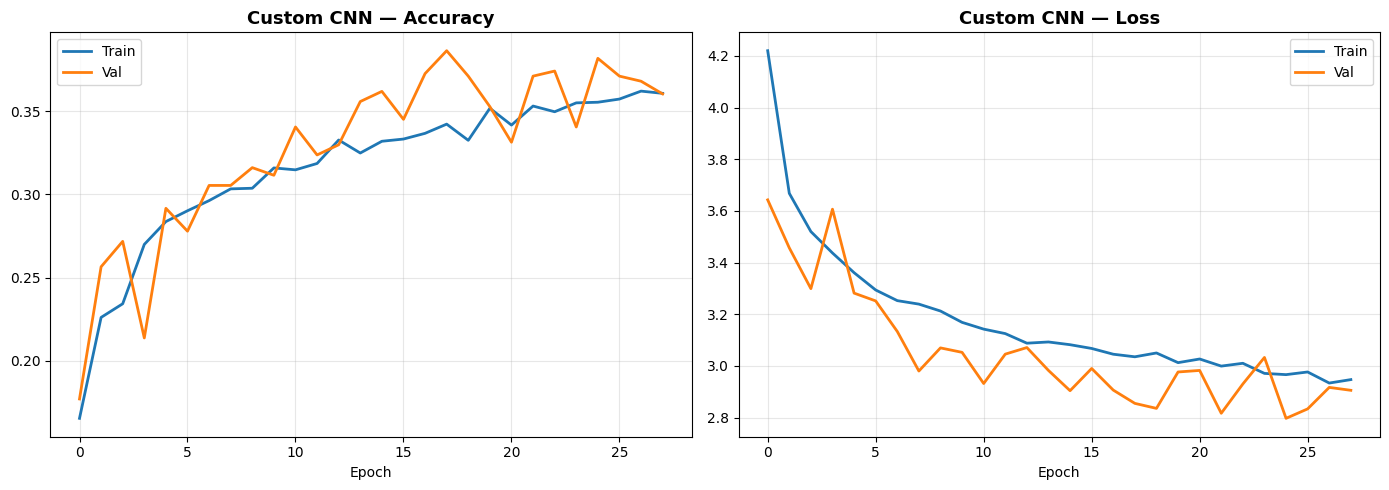

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     lw=2, label='Train')
axes[0].plot(history.history['val_accuracy'], lw=2, label='Val')
axes[0].set_title('Custom CNN — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['loss'],     lw=2, label='Train')
axes[1].plot(history.history['val_loss'], lw=2, label='Val')
axes[1].set_title('Custom CNN — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
print("Running streaming predictions on test set …")
y_pred_list = []; y_true_list = []
test_ds.reset()
for batch_x, batch_y in test_ds:
    preds = model.predict_on_batch(batch_x)
    y_pred_list.append(np.argmax(preds,   axis=1))
    y_true_list.append(np.argmax(batch_y, axis=1))
    if len(y_pred_list) >= TEST_STP: break
y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
del y_pred_list, y_true_list; gc.collect()
n = min(len(y_pred), len(y_true)); y_pred, y_true = y_pred[:n], y_true[:n]

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Grade     : {'EXCELLENT (>=90%)' if acc>=0.90 else 'GOOD (>=80%)' if acc>=0.80 else 'Needs tuning'}")
print("\n—— Classification Report ——")
print(classification_report(y_true, y_pred, labels=np.arange(len(classes)),
                             target_names=classes, zero_division=0))

Running streaming predictions on test set …

  Accuracy  : 0.3714
  Precision : 0.3308
  Recall    : 0.3714
  F1-Score  : 0.3227
  Grade     : Needs tuning

—— Classification Report ——
                     precision    recall  f1-score   support

            Alfalfa       0.00      0.00      0.00         5
          Asparagus       0.11      0.30      0.16        10
       Blue Vervain       0.00      0.00      0.00         5
 Broadleaf Plantain       0.00      0.00      0.00         5
       Bull Thistle       0.25      0.20      0.22         5
            Cattail       0.00      0.00      0.00         5
          Chickweed       0.14      0.47      0.22        15
            Chicory       1.00      0.40      0.57         5
           Cleavers       0.00      0.00      0.00         5
          Coltsfoot       0.00      0.00      0.00         5
 Common Sow Thistle       0.33      0.10      0.15        10
      Common Yarrow       0.00      0.00      0.00         5
         Coneflower  

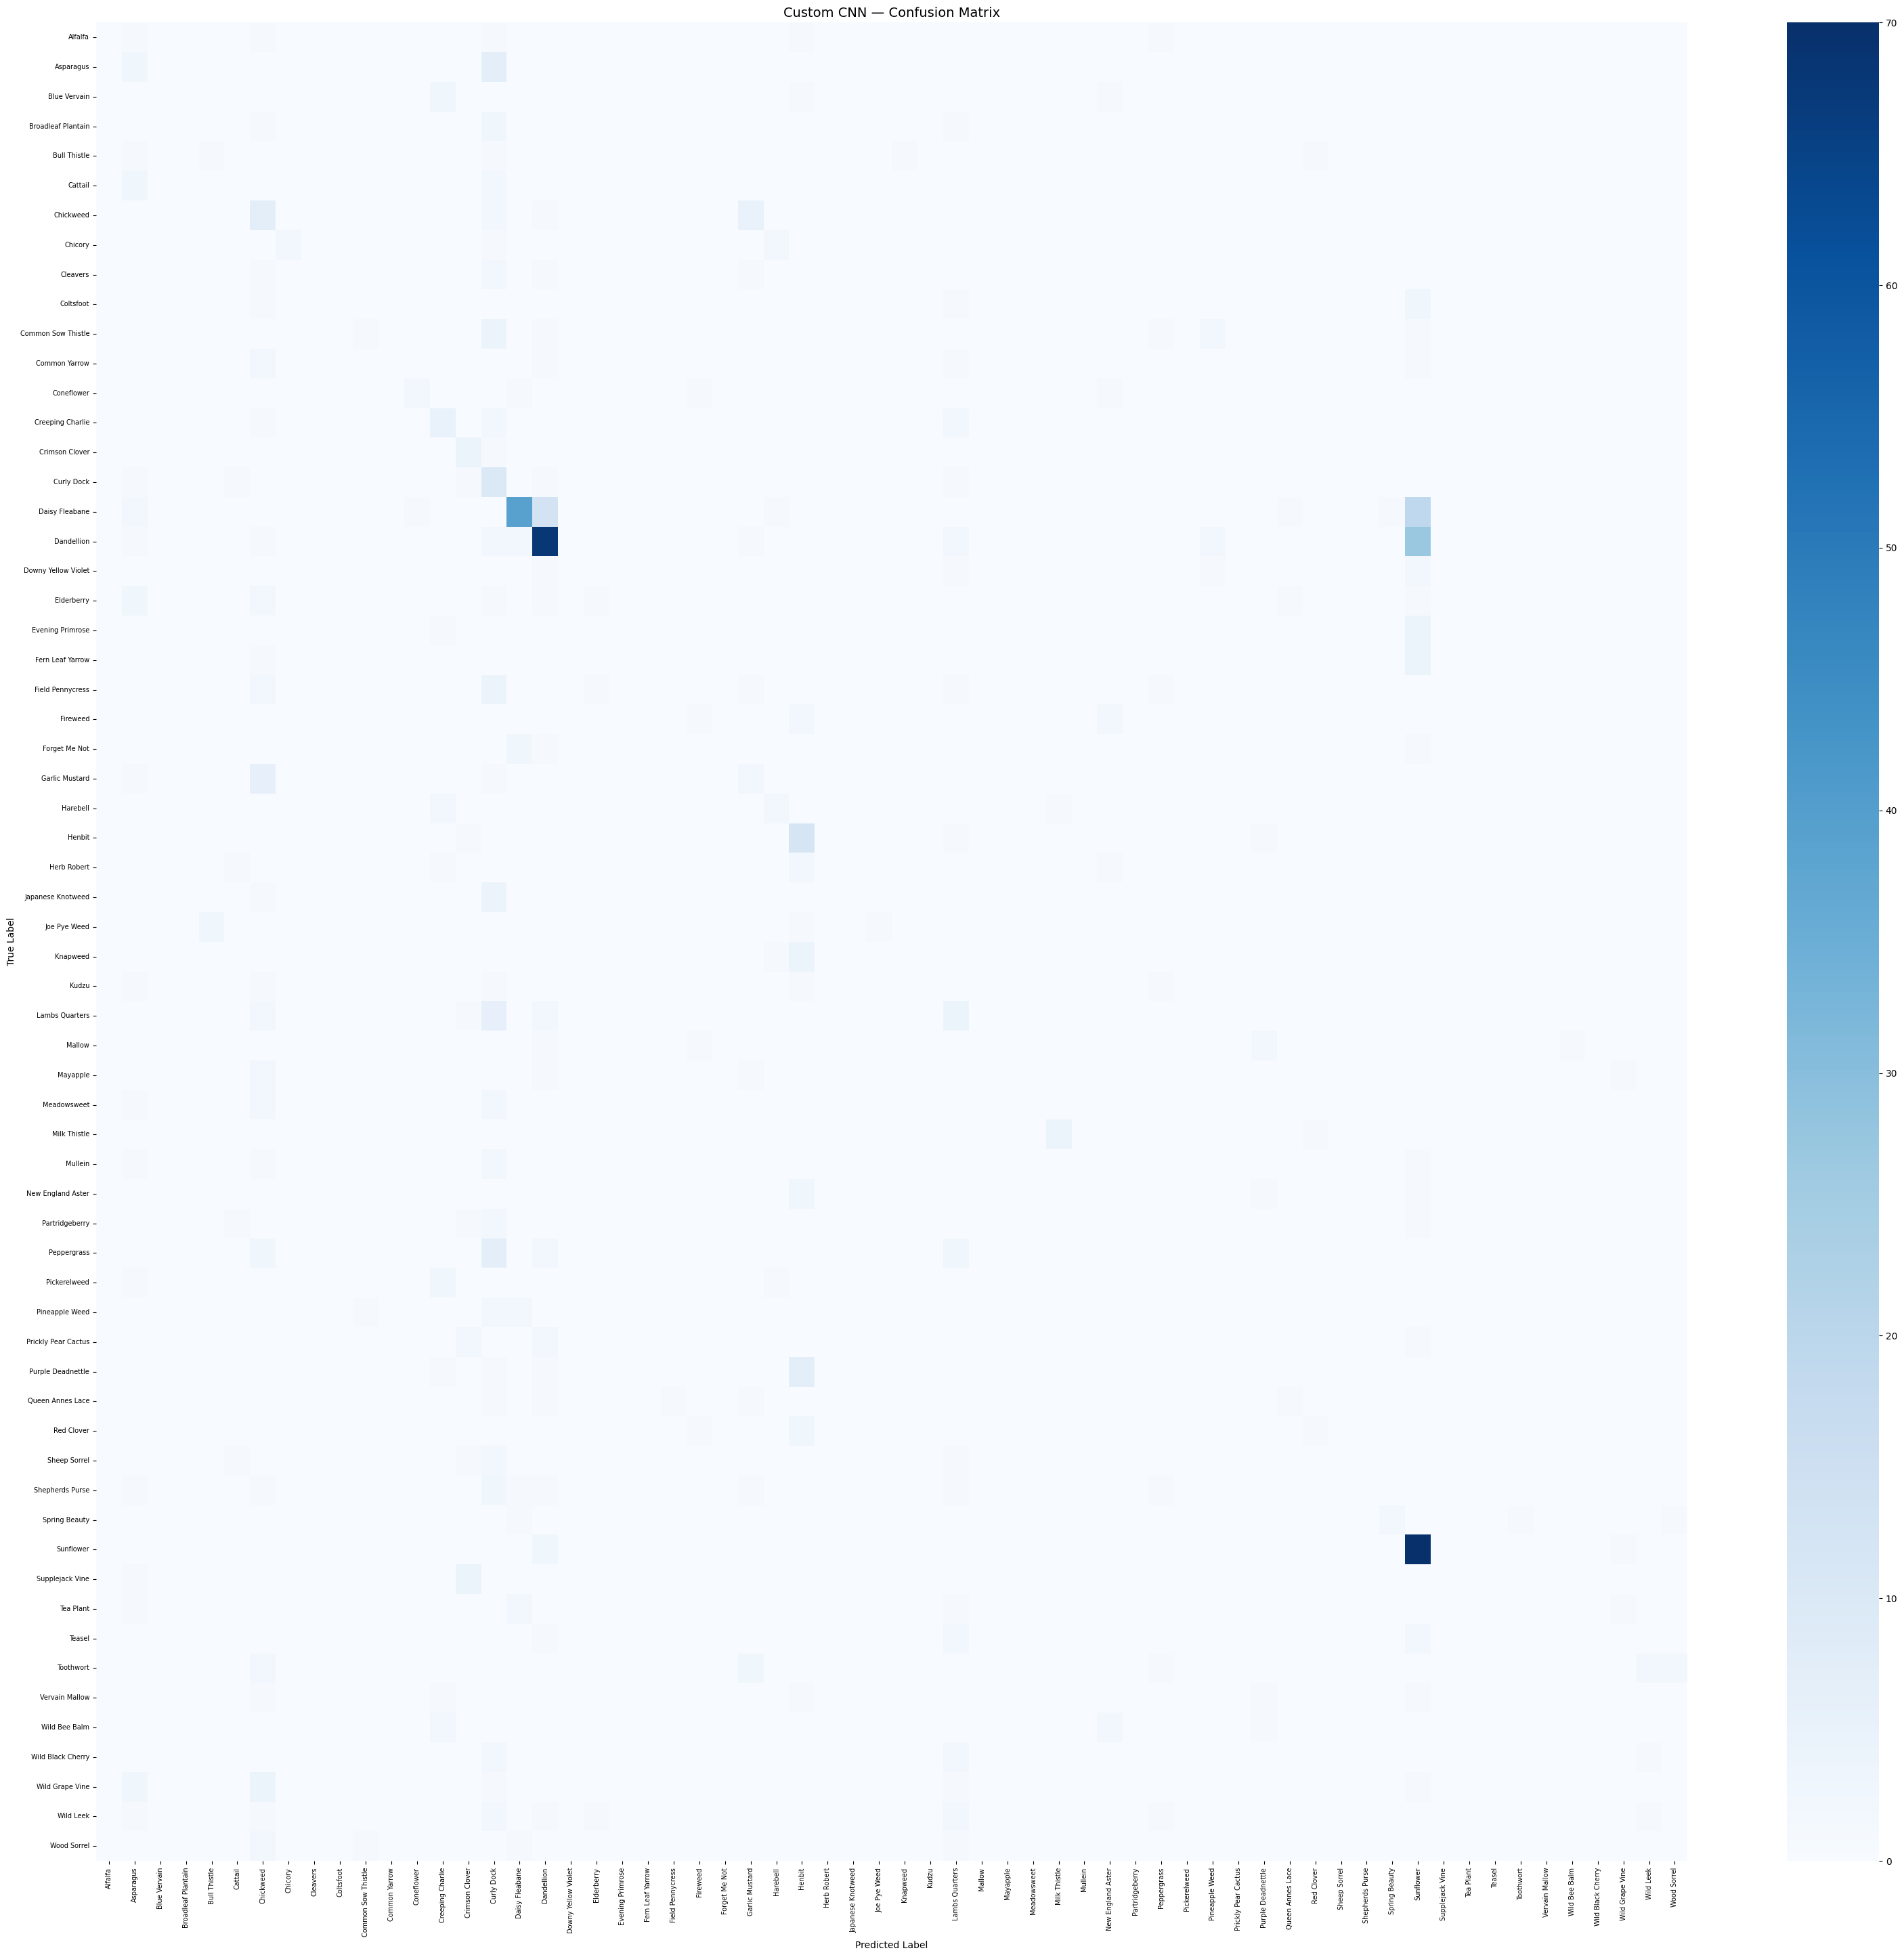

16930

In [ ]:
cm  = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
fsz = max(10, len(classes)//2)
plt.figure(figsize=(fsz, fsz-2))
sns.heatmap(cm, annot=(len(classes)<=20), fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('Custom CNN — Confusion Matrix', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()
del y_pred, y_true; gc.collect()

In [ ]:
model.save(FINAL_PATH)
print(f"Model saved: {FINAL_PATH}")
gc.collect(); tf.keras.backend.clear_session()

Model saved: /content/drive/MyDrive/edible_plants_models/CustomCNN_edible_plants.keras


In [ ]:
# ── Upload ALL saved files to Google Drive ────────────────────────────────
# Uploads: phase1 checkpoint, phase2 checkpoint, final .keras model
# Works from LOCAL machine only. Skipped automatically on Colab.
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print("Running on Colab — all files already saved to Drive. Nothing to upload.")
else:
    print("Running locally — uploading all files from saved_models/ to Google Drive …")
    try:
        import subprocess as _sp, sys as _sys
        _sp.check_call([_sys.executable, '-m', 'pip', 'install', 'pydrive2', '-q'])

        from pydrive2.auth import GoogleAuth
        from pydrive2.drive import GoogleDrive

        # One-time browser login (cached after first run)
        gauth = GoogleAuth()
        gauth.LocalWebserverAuth()
        gdrive = GoogleDrive(gauth)

        # Find or create 'edible_plants_models' folder in Drive root
        folder_list = gdrive.ListFile(
            {'q': "title='edible_plants_models' and "
                  "mimeType='application/vnd.google-apps.folder' and "
                  "trashed=false"}
        ).GetList()

        if folder_list:
            folder_id = folder_list[0]['id']
            print(f"Found Drive folder  : edible_plants_models (id={folder_id})")
        else:
            folder = gdrive.CreateFile({
                'title': 'edible_plants_models',
                'mimeType': 'application/vnd.google-apps.folder'
            })
            folder.Upload()
            folder_id = folder['id']
            print(f"Created Drive folder: edible_plants_models (id={folder_id})")

        # Upload every file inside DRIVE_DIR (saved_models/)
        all_files = [f for f in os.listdir(DRIVE_DIR)
                     if os.path.isfile(os.path.join(DRIVE_DIR, f))]

        if not all_files:
            print("No files found in saved_models/ — make sure training completed.")
        else:
            print(f"\nUploading {len(all_files)} file(s):")
            for fname in sorted(all_files):
                local_path = os.path.join(DRIVE_DIR, fname)
                size_mb = os.path.getsize(local_path) / (1024 * 1024)

                # Check if file already exists in Drive folder → update it
                existing = gdrive.ListFile(
                    {'q': f"title='{fname}' and '{folder_id}' in parents and trashed=false"}
                ).GetList()

                if existing:
                    gfile = existing[0]
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Updated  {fname:50s}  ({size_mb:.1f} MB)")
                else:
                    gfile = gdrive.CreateFile({
                        'title': fname,
                        'parents': [{'id': folder_id}]
                    })
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Uploaded {fname:50s}  ({size_mb:.1f} MB)")

            print("\nAll files uploaded to Drive/edible_plants_models/")
            print("Open modelcomparison.ipynb on Colab to compare all models.")

    except Exception as e:
        print(f"Auto-upload failed: {e}")
        print("\nManual option:")
        print(f"  Go to drive.google.com → My Drive")
        print(f"  Create folder 'edible_plants_models' if it doesn't exist")
        print(f"  Upload all files from: {DRIVE_DIR}")

Running on Colab — all files already saved to Drive. Nothing to upload.


# ResNet50V2 — Edible Plants (62 Classes)
> Works on **Google Colab** and **Local Jupyter**
> Models saved permanently — auto-uploaded to Drive from local

In [ ]:
import sys, os, gc, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Environment detection ─────────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IS_COLAB else 'Local (Jupyter)'}")
print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

Environment : Google Colab
TF version  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Storage setup (works on both Colab and Localhost) ─────────────────────
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR  = '/content/drive/MyDrive/edible_plants_models'
    DATA_ROOT  = '/content/plant_data'
else:
    # Local: save models in the project folder next to this notebook
    import pathlib
    PROJECT_DIR = str(pathlib.Path.cwd())
    DRIVE_DIR   = os.path.join(PROJECT_DIR, 'saved_models')
    DATA_ROOT   = os.path.join(PROJECT_DIR, 'plant_data')

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

print(f"Model save dir : {DRIVE_DIR}")
print(f"Data root      : {DATA_ROOT}")

Mounted at /content/drive
Model save dir : /content/drive/MyDrive/edible_plants_models
Data root      : /content/plant_data


In [ ]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

Using Colab cache for faster access to the 'edible-wild-plants' dataset.
Dataset path: /kaggle/input/edible-wild-plants


In [ ]:
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
if SOURCE_DIR is None:
    raise RuntimeError("Cannot find class root — re-run dataset download")

GOOD_FOLDERS = [d for d in sorted(os.listdir(SOURCE_DIR))
                if os.path.isdir(os.path.join(SOURCE_DIR, d))
                and any(f.lower().endswith(('.jpg','.jpeg','.png'))
                        for f in os.listdir(os.path.join(SOURCE_DIR, d)))]
print(f"SOURCE_DIR         : {SOURCE_DIR}")
print(f"Valid class folders: {len(GOOD_FOLDERS)}")

SOURCE_DIR         : /kaggle/input/edible-wild-plants/datasets/dataset
Valid class folders: 62


In [ ]:
# Only rebuild if train folder doesn't exist or is empty
if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
    if os.path.exists(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT)

    def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
        random.seed(seed); skipped = []
        for cls in classes:
            src = os.path.join(source, cls)
            imgs = [f for f in os.listdir(src)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                    and os.path.isfile(os.path.join(src, f))]
            if len(imgs) < 5: skipped.append(cls); continue
            random.shuffle(imgs)
            n_tr = int(len(imgs) * train_r)
            n_v  = max(int(len(imgs) * val_r), 1)
            for dest, flist in [
                (os.path.join(base,'train',cls), imgs[:n_tr]),
                (os.path.join(base,'val',  cls), imgs[n_tr:n_tr+n_v]),
                (os.path.join(base,'test', cls), imgs[n_tr+n_v:])
            ]:
                os.makedirs(dest, exist_ok=True)
                for f in flist:
                    shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
        return skipped

    print("Creating 80/10/10 split …")
    skipped = make_split(SOURCE_DIR, DATA_ROOT, GOOD_FOLDERS)
    if skipped: print(f"Skipped (too few images): {skipped}")
else:
    print("Split already exists — skipping rebuild.")

for split, d in [('train',TRAIN_DIR),('val',VAL_DIR),('test',TEST_DIR)]:
    if os.path.exists(d):
        nc = len([c for c in os.listdir(d) if os.path.isdir(os.path.join(d,c))])
        ni = sum(len(os.listdir(os.path.join(d,c)))
                 for c in os.listdir(d) if os.path.isdir(os.path.join(d,c)))
        print(f"  {split}: {nc} classes, {ni} images")

Creating 80/10/10 split …
  train: 62 classes, 5246 images
  val: 62 classes, 655 images
  test: 62 classes, 657 images


In [ ]:
IMG_SIZE = (224, 224); BATCH_SIZE = 8; SEED = 42
tf.keras.backend.clear_session(); gc.collect()
from tensorflow.keras.applications.resnet_v2 import preprocess_input
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
    rotation_range=30, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
vt_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
val_ds   = vt_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
test_ds  = vt_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
classes = list(train_ds.class_indices.keys()); NUM_CLASSES = len(classes)
STEPS    = max(int(np.ceil(train_ds.samples / BATCH_SIZE)), 1)
VAL_STP  = max(int(np.ceil(val_ds.samples   / BATCH_SIZE)), 1)
TEST_STP = max(int(np.ceil(test_ds.samples  / BATCH_SIZE)), 1)
print(f"Classes:{NUM_CLASSES}  Train:{train_ds.samples}  Val:{val_ds.samples}  Test:{test_ds.samples}")

Found 5246 images belonging to 62 classes.
Found 655 images belonging to 62 classes.
Found 657 images belonging to 62 classes.
Classes:62  Train:5246  Val:655  Test:657


In [ ]:
tf.keras.backend.clear_session(); gc.collect()
base_model = tf.keras.applications.ResNet50V2(input_shape=(*IMG_SIZE,3),
    include_top=False, weights='imagenet')
base_model.trainable = False
inp = layers.Input(shape=(*IMG_SIZE,3))
x = base_model(inp, training=False)
x = layers.GlobalAveragePooling2D()(x); x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inp, out); model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,769,342 (94.49 MB)

 Trainable params: 1,200,446 (4.58 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [ ]:
P1_CKPT    = os.path.join(DRIVE_DIR, 'ResNet50_phase1_best.weights.h5')
FINAL_PATH = os.path.join(DRIVE_DIR, 'ResNet50_edible_plants.keras')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p1 = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-7, verbose=1),
         ModelCheckpoint(P1_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 1 checkpoint -> {P1_CKPT}")
print("=== Phase 1: Head training (base FROZEN) ===")
h1 = model.fit(train_ds, epochs=25, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p1, verbose=1)
print(f"Phase 1 best val_accuracy: {max(h1.history['val_accuracy']):.4f}")
gc.collect()

Phase 1 checkpoint -> /content/drive/MyDrive/edible_plants_models/ResNet50_phase1_best.weights.h5
=== Phase 1: Head training (base FROZEN) ===
Epoch 1/25
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2552 - auc: 0.7530 - loss: 3.7757 - precision: 0.7222 - recall: 0.1520
Epoch 1: val_accuracy improved from None to 0.42901, saving model to /content/drive/MyDrive/edible_plants_models/ResNet50_phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/ResNet50_phase1_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 130s 176ms/step - accuracy: 0.3050 - auc: 0.8002 - loss: 3.4835 - precision: 0.8025 - recall: 0.1805 - val_accuracy: 0.4290 - val_auc: 0.9108 - val_loss: 2.8809 - val_precision: 0.9432 - val_recall: 0.2534 - learning_rate: 0.0010
Epoch 2/25
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3780 - auc: 0.8643 - loss: 3.1513 - precision: 0.8508 - recall: 0.2281
Epoch 2: val_accuracy improved from 0.42901 to 0.48244, saving m

2091

In [ ]:
P2_CKPT = os.path.join(DRIVE_DIR, 'ResNet50_phase2_best.weights.h5')
model.load_weights(P1_CKPT)
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False
for layer in base_model.layers[:-50]: layer.trainable = False
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=max(STEPS*40,1), alpha=1e-7)
model.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p2 = [EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
         ModelCheckpoint(P2_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 2 checkpoint -> {P2_CKPT}")
print("=== Phase 2: Fine-tuning top-50 base layers ===")
gc.collect()
h2 = model.fit(train_ds, epochs=10, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p2, verbose=1)
print(f"Phase 2 best val_accuracy: {max(h2.history['val_accuracy']):.4f}")
gc.collect()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 57 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Phase 2 checkpoint -> /content/drive/MyDrive/edible_plants_models/ResNet50_phase2_best.weights.h5
=== Phase 2: Fine-tuning top-50 base layers ===
Epoch 1/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.6291 - auc: 0.9726 - loss: 2.0602 - precision: 0.8610 - recall: 0.4458
Epoch 1: val_accuracy improved from None to 0.68397, saving model to /content/drive/MyDrive/edible_plants_models/ResNet50_phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/ResNet50_phase2_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 132s 177ms/step - accuracy: 0.6390 - auc: 0.9717 - loss: 2.0363 - precision: 0.8635 - recall: 0.4653 - val_accuracy: 0.6840 - val_auc: 0.9790 - val_loss: 1.8841 - val_precision: 0.8673 - val_recall: 0.5389
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6505 - auc: 0.9736 - loss: 1.9813 - precision: 0.8728 - recall: 0.5034
Epoch 2: val_accuracy improved from 0.68397 to 0.72366, saving model to /content/driv

1993

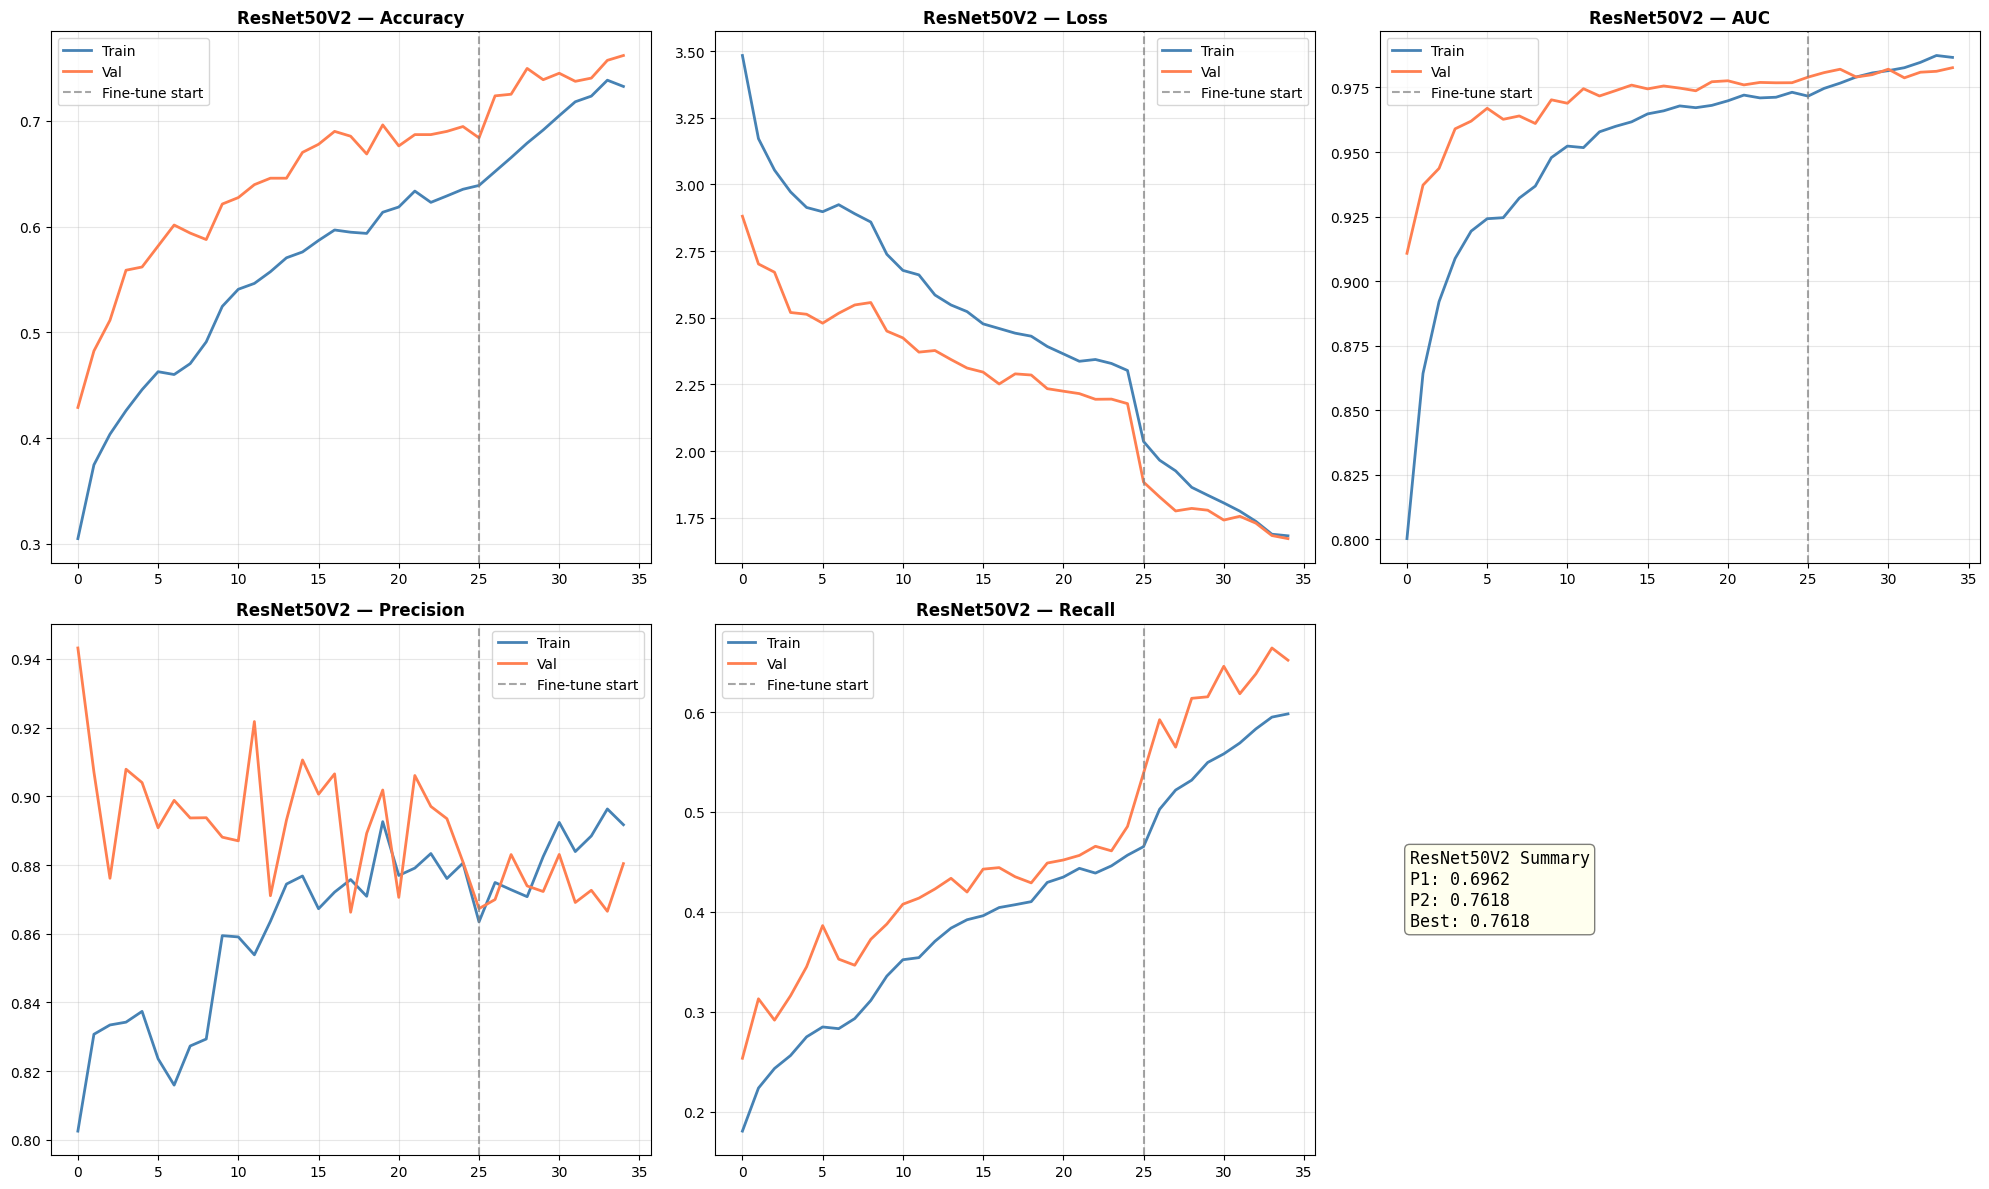

In [ ]:
def combine(h1, h2, key): return h1.history.get(key,[]) + h2.history.get(key,[])
phase1_end = len(h1.history['accuracy'])
pairs = [('accuracy','val_accuracy','Accuracy'),('loss','val_loss','Loss'),
         ('auc','val_auc','AUC'),('precision','val_precision','Precision'),('recall','val_recall','Recall')]
fig, axes = plt.subplots(2, 3, figsize=(20,12))
for ax,(tr,vl,title) in zip(axes.flat, pairs):
    ax.plot(combine(h1,h2,tr), color='steelblue', lw=2, label='Train')
    ax.plot(combine(h1,h2,vl), color='coral',     lw=2, label='Val')
    ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(f'ResNet50V2 — {title}', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
ax_s = axes.flat[-1]; ax_s.axis('off')
ax_s.text(0.05,0.5, f"ResNet50V2 Summary\nP1: {max(h1.history['val_accuracy']):.4f}\nP2: {max(h2.history['val_accuracy']):.4f}\nBest: {max(combine(h1,h2,'val_accuracy')):.4f}",
    fontsize=12,family='monospace',verticalalignment='center',
    bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.5))
plt.tight_layout(); plt.show()

In [ ]:
print("Running streaming predictions on test set …")
y_pred_list = []; y_true_list = []
test_ds.reset()
for batch_x, batch_y in test_ds:
    preds = model.predict_on_batch(batch_x)
    y_pred_list.append(np.argmax(preds,   axis=1))
    y_true_list.append(np.argmax(batch_y, axis=1))
    if len(y_pred_list) >= TEST_STP: break
y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
del y_pred_list, y_true_list; gc.collect()
n = min(len(y_pred), len(y_true)); y_pred, y_true = y_pred[:n], y_true[:n]

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Grade     : {'EXCELLENT (>=90%)' if acc>=0.90 else 'GOOD (>=80%)' if acc>=0.80 else 'Needs tuning'}")
print("\n—— Classification Report ——")
print(classification_report(y_true, y_pred, labels=np.arange(len(classes)),
                             target_names=classes, zero_division=0))

Running streaming predictions on test set …

  Accuracy  : 0.7489
  Precision : 0.7646
  Recall    : 0.7489
  F1-Score  : 0.7420
  Grade     : Needs tuning

—— Classification Report ——
                     precision    recall  f1-score   support

            Alfalfa       0.50      0.20      0.29         5
          Asparagus       0.78      0.70      0.74        10
       Blue Vervain       0.75      0.60      0.67         5
 Broadleaf Plantain       0.43      0.60      0.50         5
       Bull Thistle       0.40      0.40      0.40         5
            Cattail       0.62      1.00      0.77         5
          Chickweed       0.65      0.73      0.69        15
            Chicory       0.75      0.60      0.67         5
           Cleavers       1.00      0.80      0.89         5
          Coltsfoot       0.80      0.80      0.80         5
 Common Sow Thistle       0.78      0.70      0.74        10
      Common Yarrow       1.00      0.20      0.33         5
         Coneflower  

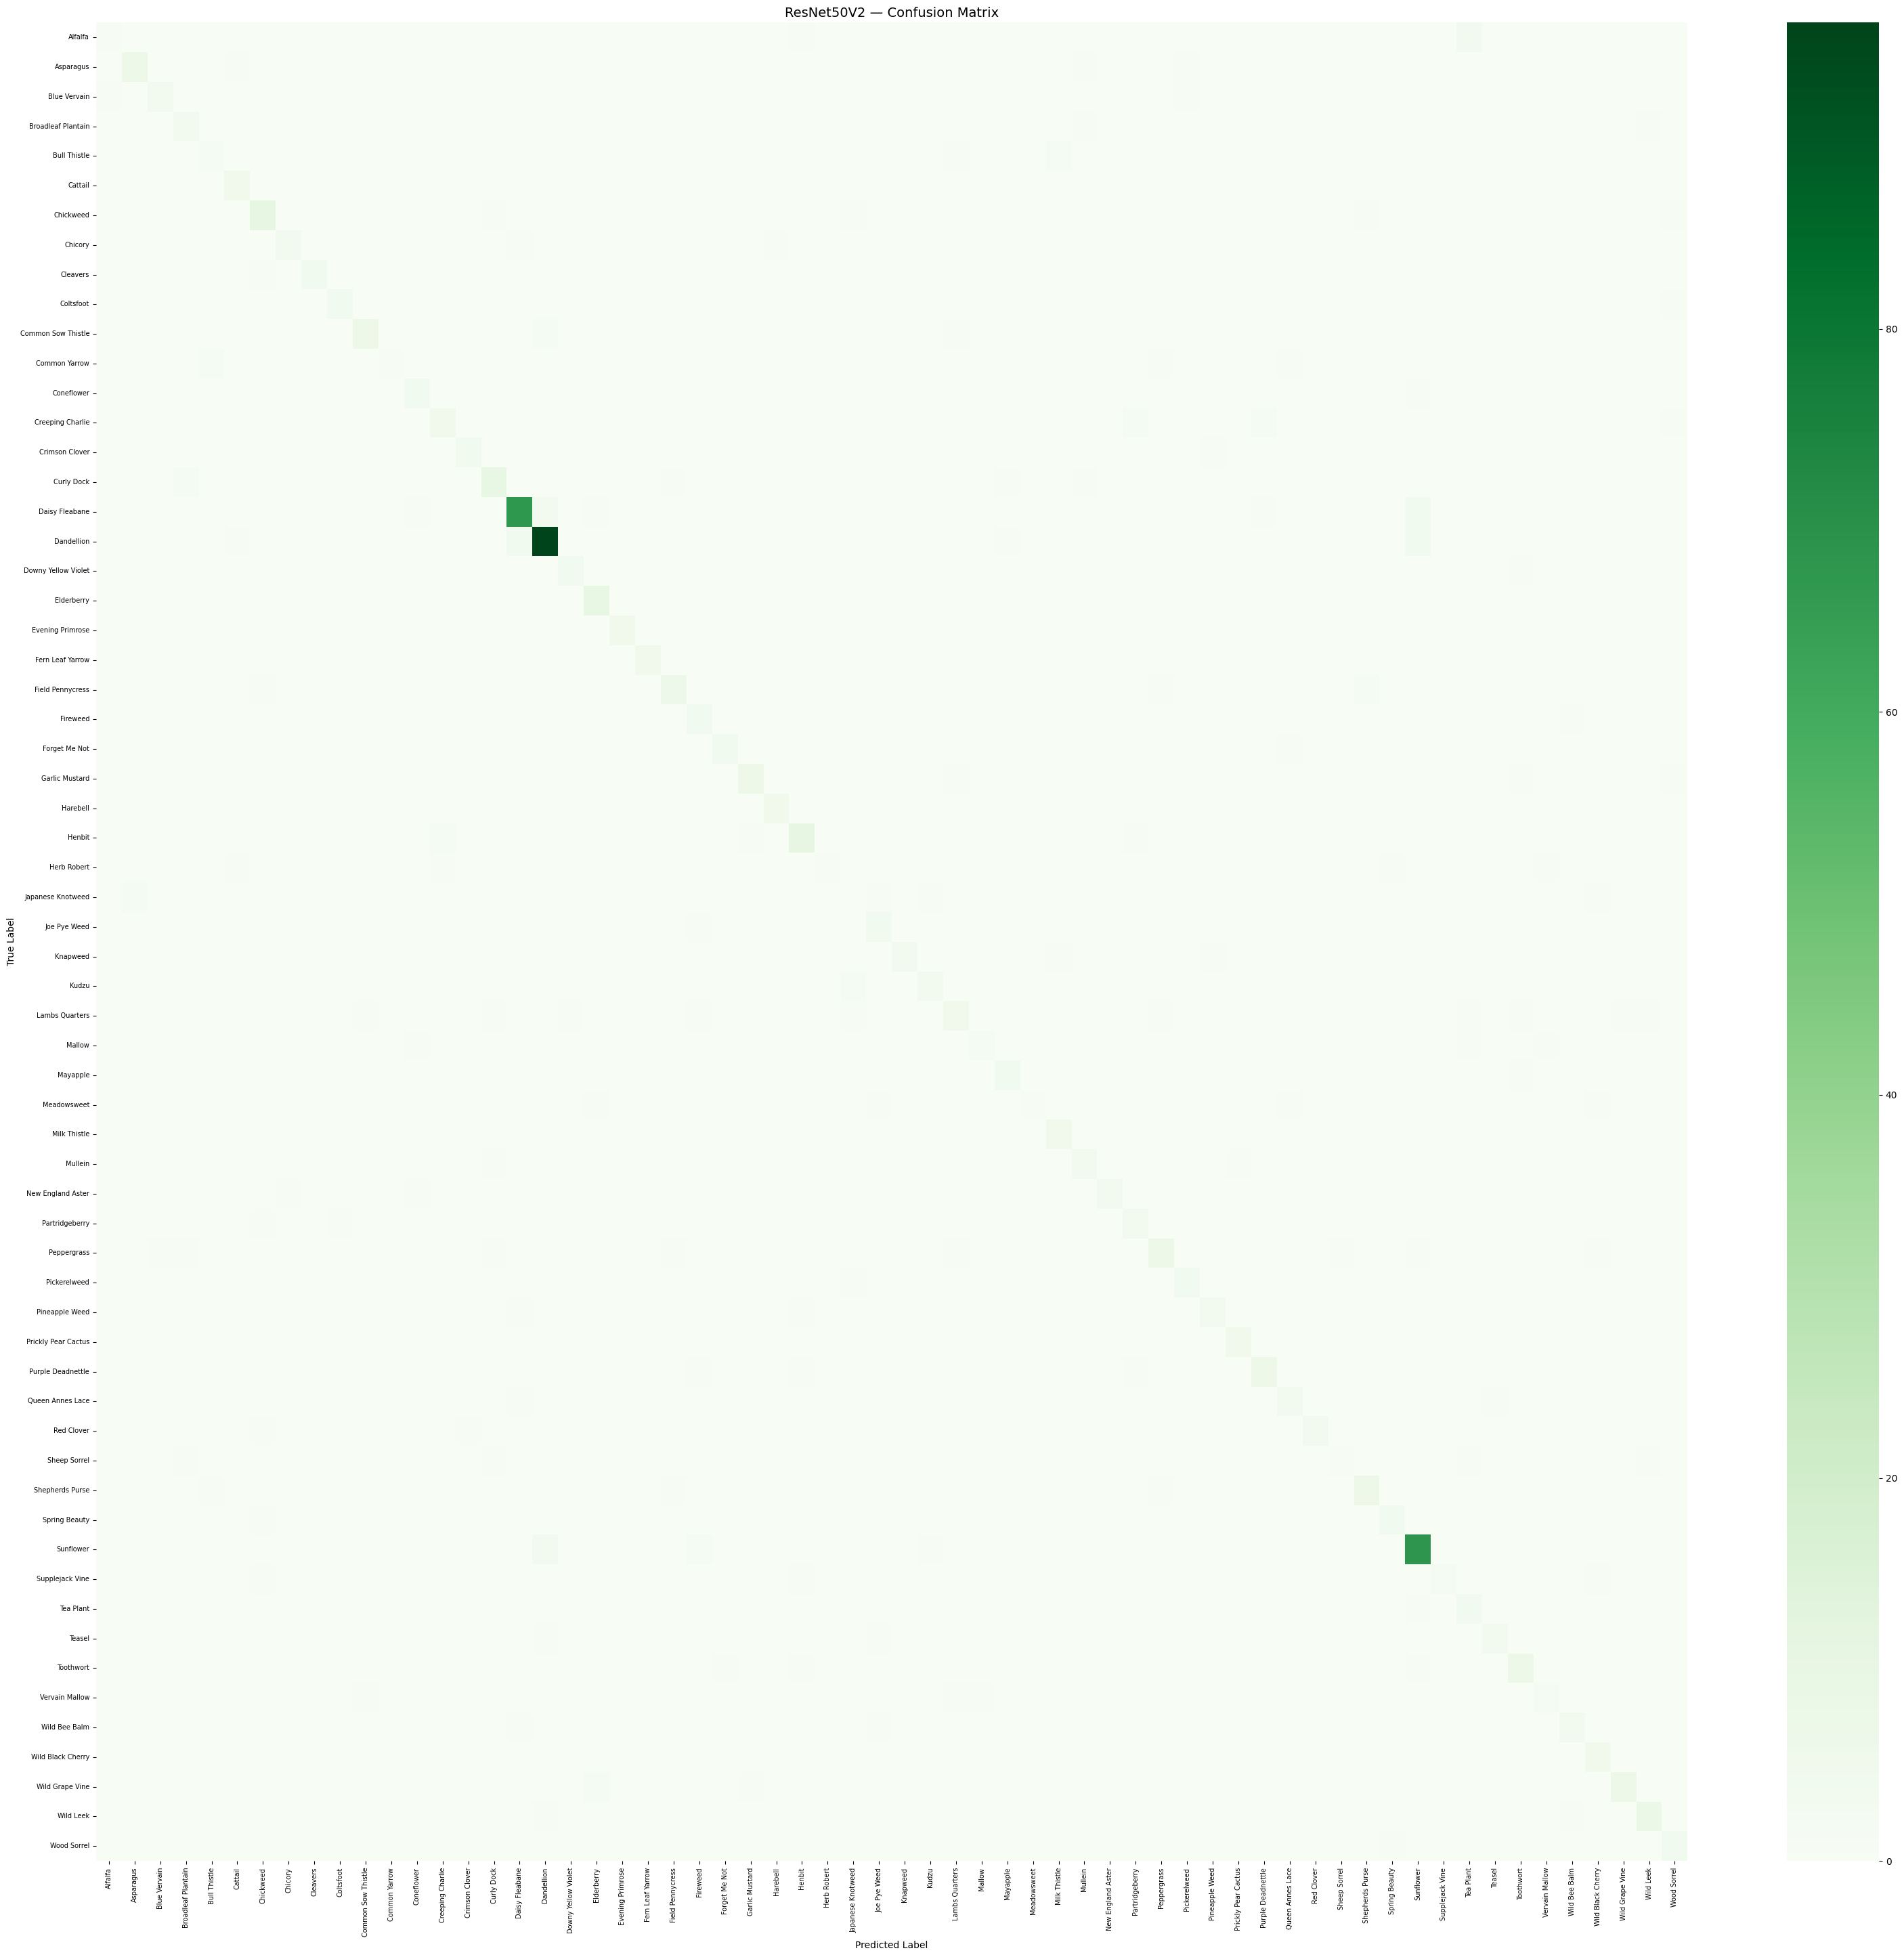

16524

In [ ]:
cm  = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
fsz = max(10, len(classes)//2)
plt.figure(figsize=(fsz, fsz-2))
sns.heatmap(cm, annot=(len(classes)<=20), fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Greens')
plt.title('ResNet50V2 — Confusion Matrix', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()
del y_pred, y_true; gc.collect()

In [ ]:
model.save(FINAL_PATH)
print(f"Model saved: {FINAL_PATH}")
gc.collect(); tf.keras.backend.clear_session()

Model saved: /content/drive/MyDrive/edible_plants_models/ResNet50_edible_plants.keras


In [ ]:
# ── Upload ALL saved files to Google Drive ────────────────────────────────
# Uploads: phase1 checkpoint, phase2 checkpoint, final .keras model
# Works from LOCAL machine only. Skipped automatically on Colab.
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print("Running on Colab — all files already saved to Drive. Nothing to upload.")
else:
    print("Running locally — uploading all files from saved_models/ to Google Drive …")
    try:
        import subprocess as _sp, sys as _sys
        _sp.check_call([_sys.executable, '-m', 'pip', 'install', 'pydrive2', '-q'])

        from pydrive2.auth import GoogleAuth
        from pydrive2.drive import GoogleDrive

        # One-time browser login (cached after first run)
        gauth = GoogleAuth()
        gauth.LocalWebserverAuth()
        gdrive = GoogleDrive(gauth)

        # Find or create 'edible_plants_models' folder in Drive root
        folder_list = gdrive.ListFile(
            {'q': "title='edible_plants_models' and "
                  "mimeType='application/vnd.google-apps.folder' and "
                  "trashed=false"}
        ).GetList()

        if folder_list:
            folder_id = folder_list[0]['id']
            print(f"Found Drive folder  : edible_plants_models (id={folder_id})")
        else:
            folder = gdrive.CreateFile({
                'title': 'edible_plants_models',
                'mimeType': 'application/vnd.google-apps.folder'
            })
            folder.Upload()
            folder_id = folder['id']
            print(f"Created Drive folder: edible_plants_models (id={folder_id})")

        # Upload every file inside DRIVE_DIR (saved_models/)
        all_files = [f for f in os.listdir(DRIVE_DIR)
                     if os.path.isfile(os.path.join(DRIVE_DIR, f))]

        if not all_files:
            print("No files found in saved_models/ — make sure training completed.")
        else:
            print(f"\nUploading {len(all_files)} file(s):")
            for fname in sorted(all_files):
                local_path = os.path.join(DRIVE_DIR, fname)
                size_mb = os.path.getsize(local_path) / (1024 * 1024)

                # Check if file already exists in Drive folder → update it
                existing = gdrive.ListFile(
                    {'q': f"title='{fname}' and '{folder_id}' in parents and trashed=false"}
                ).GetList()

                if existing:
                    gfile = existing[0]
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Updated  {fname:50s}  ({size_mb:.1f} MB)")
                else:
                    gfile = gdrive.CreateFile({
                        'title': fname,
                        'parents': [{'id': folder_id}]
                    })
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Uploaded {fname:50s}  ({size_mb:.1f} MB)")

            print("\nAll files uploaded to Drive/edible_plants_models/")
            print("Open modelcomparison.ipynb on Colab to compare all models.")

    except Exception as e:
        print(f"Auto-upload failed: {e}")
        print("\nManual option:")
        print(f"  Go to drive.google.com → My Drive")
        print(f"  Create folder 'edible_plants_models' if it doesn't exist")
        print(f"  Upload all files from: {DRIVE_DIR}")

Running on Colab — all files already saved to Drive. Nothing to upload.


# MobileNetV2 — Edible Plants (62 Classes)
> Works on **Google Colab** and **Local Jupyter** · Target ≥90%
> Models saved permanently — auto-uploaded to Drive from local

In [ ]:
import sys, os, gc, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Environment detection ─────────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IS_COLAB else 'Local (Jupyter)'}")
print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

Environment : Google Colab
TF version  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Storage setup (works on both Colab and Localhost) ─────────────────────
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR  = '/content/drive/MyDrive/edible_plants_models'
    DATA_ROOT  = '/content/plant_data'
else:
    # Local: save models in the project folder next to this notebook
    import pathlib
    PROJECT_DIR = str(pathlib.Path.cwd())
    DRIVE_DIR   = os.path.join(PROJECT_DIR, 'saved_models')
    DATA_ROOT   = os.path.join(PROJECT_DIR, 'plant_data')

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

print(f"Model save dir : {DRIVE_DIR}")
print(f"Data root      : {DATA_ROOT}")

Mounted at /content/drive
Model save dir : /content/drive/MyDrive/edible_plants_models
Data root      : /content/plant_data


In [ ]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

100%|██████████| 766M/766M [00:08<00:00, 95.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5


In [ ]:
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
if SOURCE_DIR is None:
    raise RuntimeError("Cannot find class root — re-run dataset download")

GOOD_FOLDERS = [d for d in sorted(os.listdir(SOURCE_DIR))
                if os.path.isdir(os.path.join(SOURCE_DIR, d))
                and any(f.lower().endswith(('.jpg','.jpeg','.png'))
                        for f in os.listdir(os.path.join(SOURCE_DIR, d)))]
print(f"SOURCE_DIR         : {SOURCE_DIR}")
print(f"Valid class folders: {len(GOOD_FOLDERS)}")

SOURCE_DIR         : /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5/datasets/dataset
Valid class folders: 62


In [ ]:
# Only rebuild if train folder doesn't exist or is empty
if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
    if os.path.exists(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT)

    def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
        random.seed(seed); skipped = []
        for cls in classes:
            src = os.path.join(source, cls)
            imgs = [f for f in os.listdir(src)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                    and os.path.isfile(os.path.join(src, f))]
            if len(imgs) < 5: skipped.append(cls); continue
            random.shuffle(imgs)
            n_tr = int(len(imgs) * train_r)
            n_v  = max(int(len(imgs) * val_r), 1)
            for dest, flist in [
                (os.path.join(base,'train',cls), imgs[:n_tr]),
                (os.path.join(base,'val',  cls), imgs[n_tr:n_tr+n_v]),
                (os.path.join(base,'test', cls), imgs[n_tr+n_v:])
            ]:
                os.makedirs(dest, exist_ok=True)
                for f in flist:
                    shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
        return skipped

    print("Creating 80/10/10 split …")
    skipped = make_split(SOURCE_DIR, DATA_ROOT, GOOD_FOLDERS)
    if skipped: print(f"Skipped (too few images): {skipped}")
else:
    print("Split already exists — skipping rebuild.")

for split, d in [('train',TRAIN_DIR),('val',VAL_DIR),('test',TEST_DIR)]:
    if os.path.exists(d):
        nc = len([c for c in os.listdir(d) if os.path.isdir(os.path.join(d,c))])
        ni = sum(len(os.listdir(os.path.join(d,c)))
                 for c in os.listdir(d) if os.path.isdir(os.path.join(d,c)))
        print(f"  {split}: {nc} classes, {ni} images")

Creating 80/10/10 split …
  train: 62 classes, 5246 images
  val: 62 classes, 655 images
  test: 62 classes, 657 images


In [ ]:
IMG_SIZE = (224, 224); BATCH_SIZE = 8; SEED = 42
tf.keras.backend.clear_session(); gc.collect()
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
    rotation_range=30, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
vt_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
val_ds   = vt_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
test_ds  = vt_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
classes = list(train_ds.class_indices.keys()); NUM_CLASSES = len(classes)
STEPS    = max(int(np.ceil(train_ds.samples / BATCH_SIZE)), 1)
VAL_STP  = max(int(np.ceil(val_ds.samples   / BATCH_SIZE)), 1)
TEST_STP = max(int(np.ceil(test_ds.samples  / BATCH_SIZE)), 1)
print(f"Classes:{NUM_CLASSES}  Train:{train_ds.samples}  Val:{val_ds.samples}  Test:{test_ds.samples}")

Found 5246 images belonging to 62 classes.
Found 655 images belonging to 62 classes.
Found 657 images belonging to 62 classes.
Classes:62  Train:5246  Val:655  Test:657


In [ ]:
tf.keras.backend.clear_session(); gc.collect()
base_model = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE,3),
    include_top=False, weights='imagenet')
base_model.trainable = False
inp = layers.Input(shape=(*IMG_SIZE,3))
x = base_model(inp, training=False)
x = layers.GlobalAveragePooling2D()(x); x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inp, out); model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,066,238 (11.70 MB)

 Trainable params: 805,694 (3.07 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
P1_CKPT    = os.path.join(DRIVE_DIR, 'MobileNetV2_phase1_best.weights.h5')
FINAL_PATH = os.path.join(DRIVE_DIR, 'MobileNetV2_edible_plants.keras')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p1 = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-7, verbose=1),
         ModelCheckpoint(P1_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 1 checkpoint -> {P1_CKPT}")
print("=== Phase 1: Head training (base FROZEN) ===")
h1 = model.fit(train_ds, epochs=30, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p1, verbose=1)
print(f"Phase 1 best val_accuracy: {max(h1.history['val_accuracy']):.4f}")
gc.collect()

Phase 1 checkpoint -> /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5
=== Phase 1: Head training (base FROZEN) ===
Epoch 1/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3076 - auc: 0.7960 - loss: 3.4262 - precision: 0.7663 - recall: 0.1841
Epoch 1: val_accuracy improved from None to 0.52366, saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 147s 182ms/step - accuracy: 0.3578 - auc: 0.8486 - loss: 3.1397 - precision: 0.8154 - recall: 0.2205 - val_accuracy: 0.5237 - val_auc: 0.9439 - val_loss: 2.4507 - val_precision: 0.9035 - val_recall: 0.3145 - learning_rate: 0.0010
Epoch 2/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4289 - auc: 0.9086 - loss: 2.7950 - precision: 0.8310 - recall: 0.2588
Epoch 2: val_accuracy improved from 0.52366 to 0.54351,

2166

In [ ]:
P2_CKPT = os.path.join(DRIVE_DIR, 'MobileNetV2_phase2_best.weights.h5')
model.load_weights(P1_CKPT)
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False
for layer in base_model.layers[:-50]: layer.trainable = False
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=max(STEPS*40,1), alpha=1e-7)
model.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p2 = [EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
         ModelCheckpoint(P2_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 2 checkpoint -> {P2_CKPT}")
print("=== Phase 2: Fine-tuning top-50 base layers ===")
gc.collect()
h2 = model.fit(train_ds, epochs=15, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p2, verbose=1)
print(f"Phase 2 best val_accuracy: {max(h2.history['val_accuracy']):.4f}")
gc.collect()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 51 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Phase 2 checkpoint -> /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5
=== Phase 2: Fine-tuning top-50 base layers ===
Epoch 1/15
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7149 - auc: 0.9864 - loss: 1.5896 - precision: 0.8983 - recall: 0.5535
Epoch 1: val_accuracy improved from None to 0.70382, saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 163ms/step - accuracy: 0.7144 - auc: 0.9859 - loss: 1.5797 - precision: 0.8898 - recall: 0.5646 - val_accuracy: 0.7038 - val_auc: 0.9723 - val_loss: 1.6701 - val_precision: 0.8544 - val_recall: 0.6183
Epoch 2/15
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7402 - auc: 0.9869 - loss: 1.5199 - precision: 0.8898 - recall: 0.5937
Epoch 2: val_accuracy improved from 0.70382 to 0.72519, saving model to /con

4192

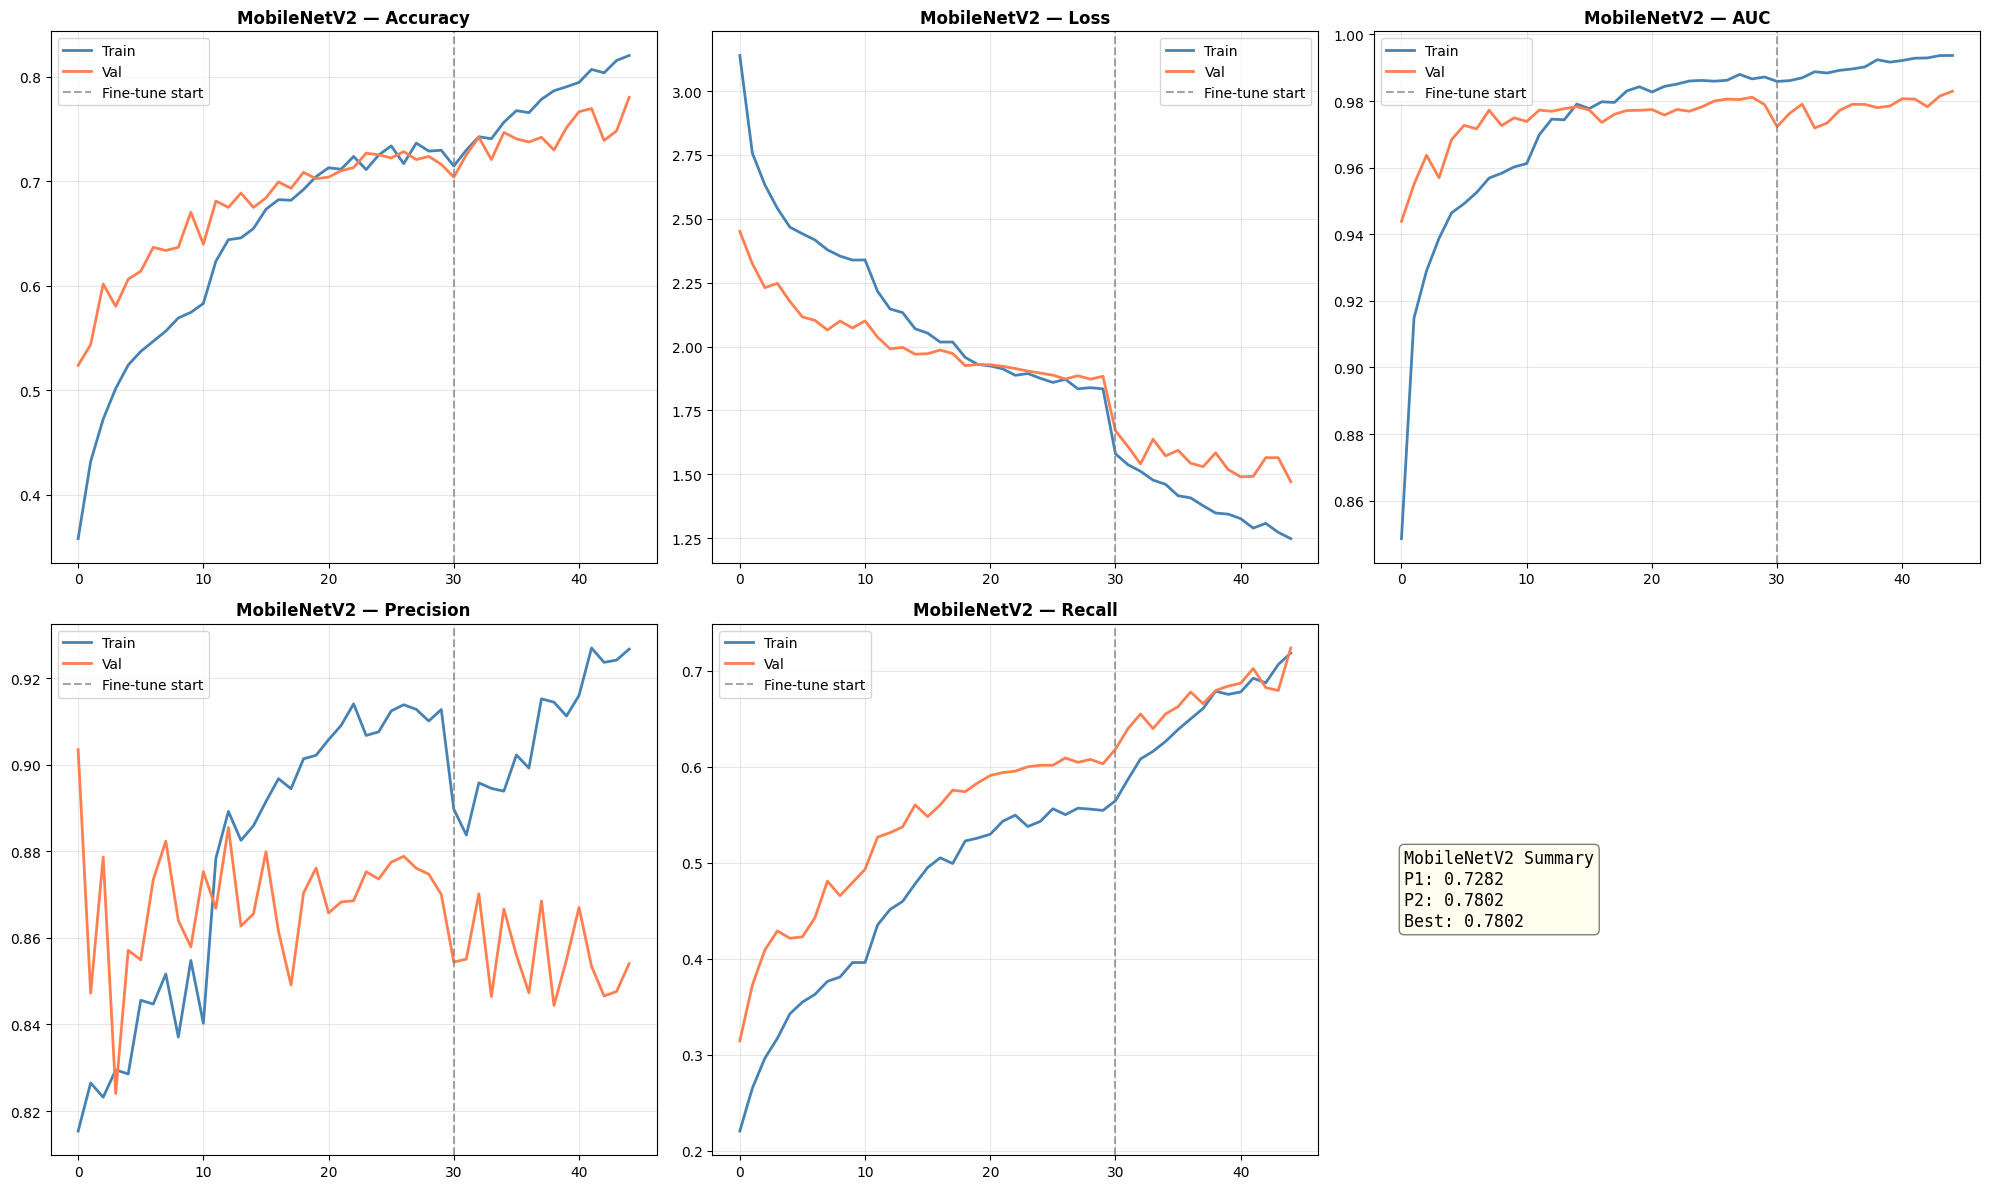

In [ ]:
def combine(h1, h2, key): return h1.history.get(key,[]) + h2.history.get(key,[])
phase1_end = len(h1.history['accuracy'])
pairs = [('accuracy','val_accuracy','Accuracy'),('loss','val_loss','Loss'),
         ('auc','val_auc','AUC'),('precision','val_precision','Precision'),('recall','val_recall','Recall')]
fig, axes = plt.subplots(2, 3, figsize=(20,12))
for ax,(tr,vl,title) in zip(axes.flat, pairs):
    ax.plot(combine(h1,h2,tr), color='steelblue', lw=2, label='Train')
    ax.plot(combine(h1,h2,vl), color='coral',     lw=2, label='Val')
    ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(f'MobileNetV2 — {title}', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
ax_s = axes.flat[-1]; ax_s.axis('off')
ax_s.text(0.05,0.5, f"MobileNetV2 Summary\nP1: {max(h1.history['val_accuracy']):.4f}\nP2: {max(h2.history['val_accuracy']):.4f}\nBest: {max(combine(h1,h2,'val_accuracy')):.4f}",
    fontsize=12,family='monospace',verticalalignment='center',
    bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.5))
plt.tight_layout(); plt.show()

In [ ]:
print("Running streaming predictions on test set …")
y_pred_list = []; y_true_list = []
test_ds.reset()
for batch_x, batch_y in test_ds:
    preds = model.predict_on_batch(batch_x)
    y_pred_list.append(np.argmax(preds,   axis=1))
    y_true_list.append(np.argmax(batch_y, axis=1))
    if len(y_pred_list) >= TEST_STP: break
y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
del y_pred_list, y_true_list; gc.collect()
n = min(len(y_pred), len(y_true)); y_pred, y_true = y_pred[:n], y_true[:n]

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Grade     : {'EXCELLENT (>=90%)' if acc>=0.90 else 'GOOD (>=80%)' if acc>=0.80 else 'Needs tuning'}")
print("\n—— Classification Report ——")
print(classification_report(y_true, y_pred, labels=np.arange(len(classes)),
                             target_names=classes, zero_division=0))

Running streaming predictions on test set …

  Accuracy  : 0.7717
  Precision : 0.7824
  Recall    : 0.7717
  F1-Score  : 0.7671
  Grade     : Needs tuning

—— Classification Report ——
                     precision    recall  f1-score   support

            Alfalfa       0.50      0.20      0.29         5
          Asparagus       1.00      0.90      0.95        10
       Blue Vervain       0.67      0.40      0.50         5
 Broadleaf Plantain       0.36      0.80      0.50         5
       Bull Thistle       0.67      0.40      0.50         5
            Cattail       1.00      1.00      1.00         5
          Chickweed       0.79      0.73      0.76        15
            Chicory       0.60      0.60      0.60         5
           Cleavers       0.40      0.40      0.40         5
          Coltsfoot       0.75      0.60      0.67         5
 Common Sow Thistle       1.00      0.60      0.75        10
      Common Yarrow       0.33      0.40      0.36         5
         Coneflower  

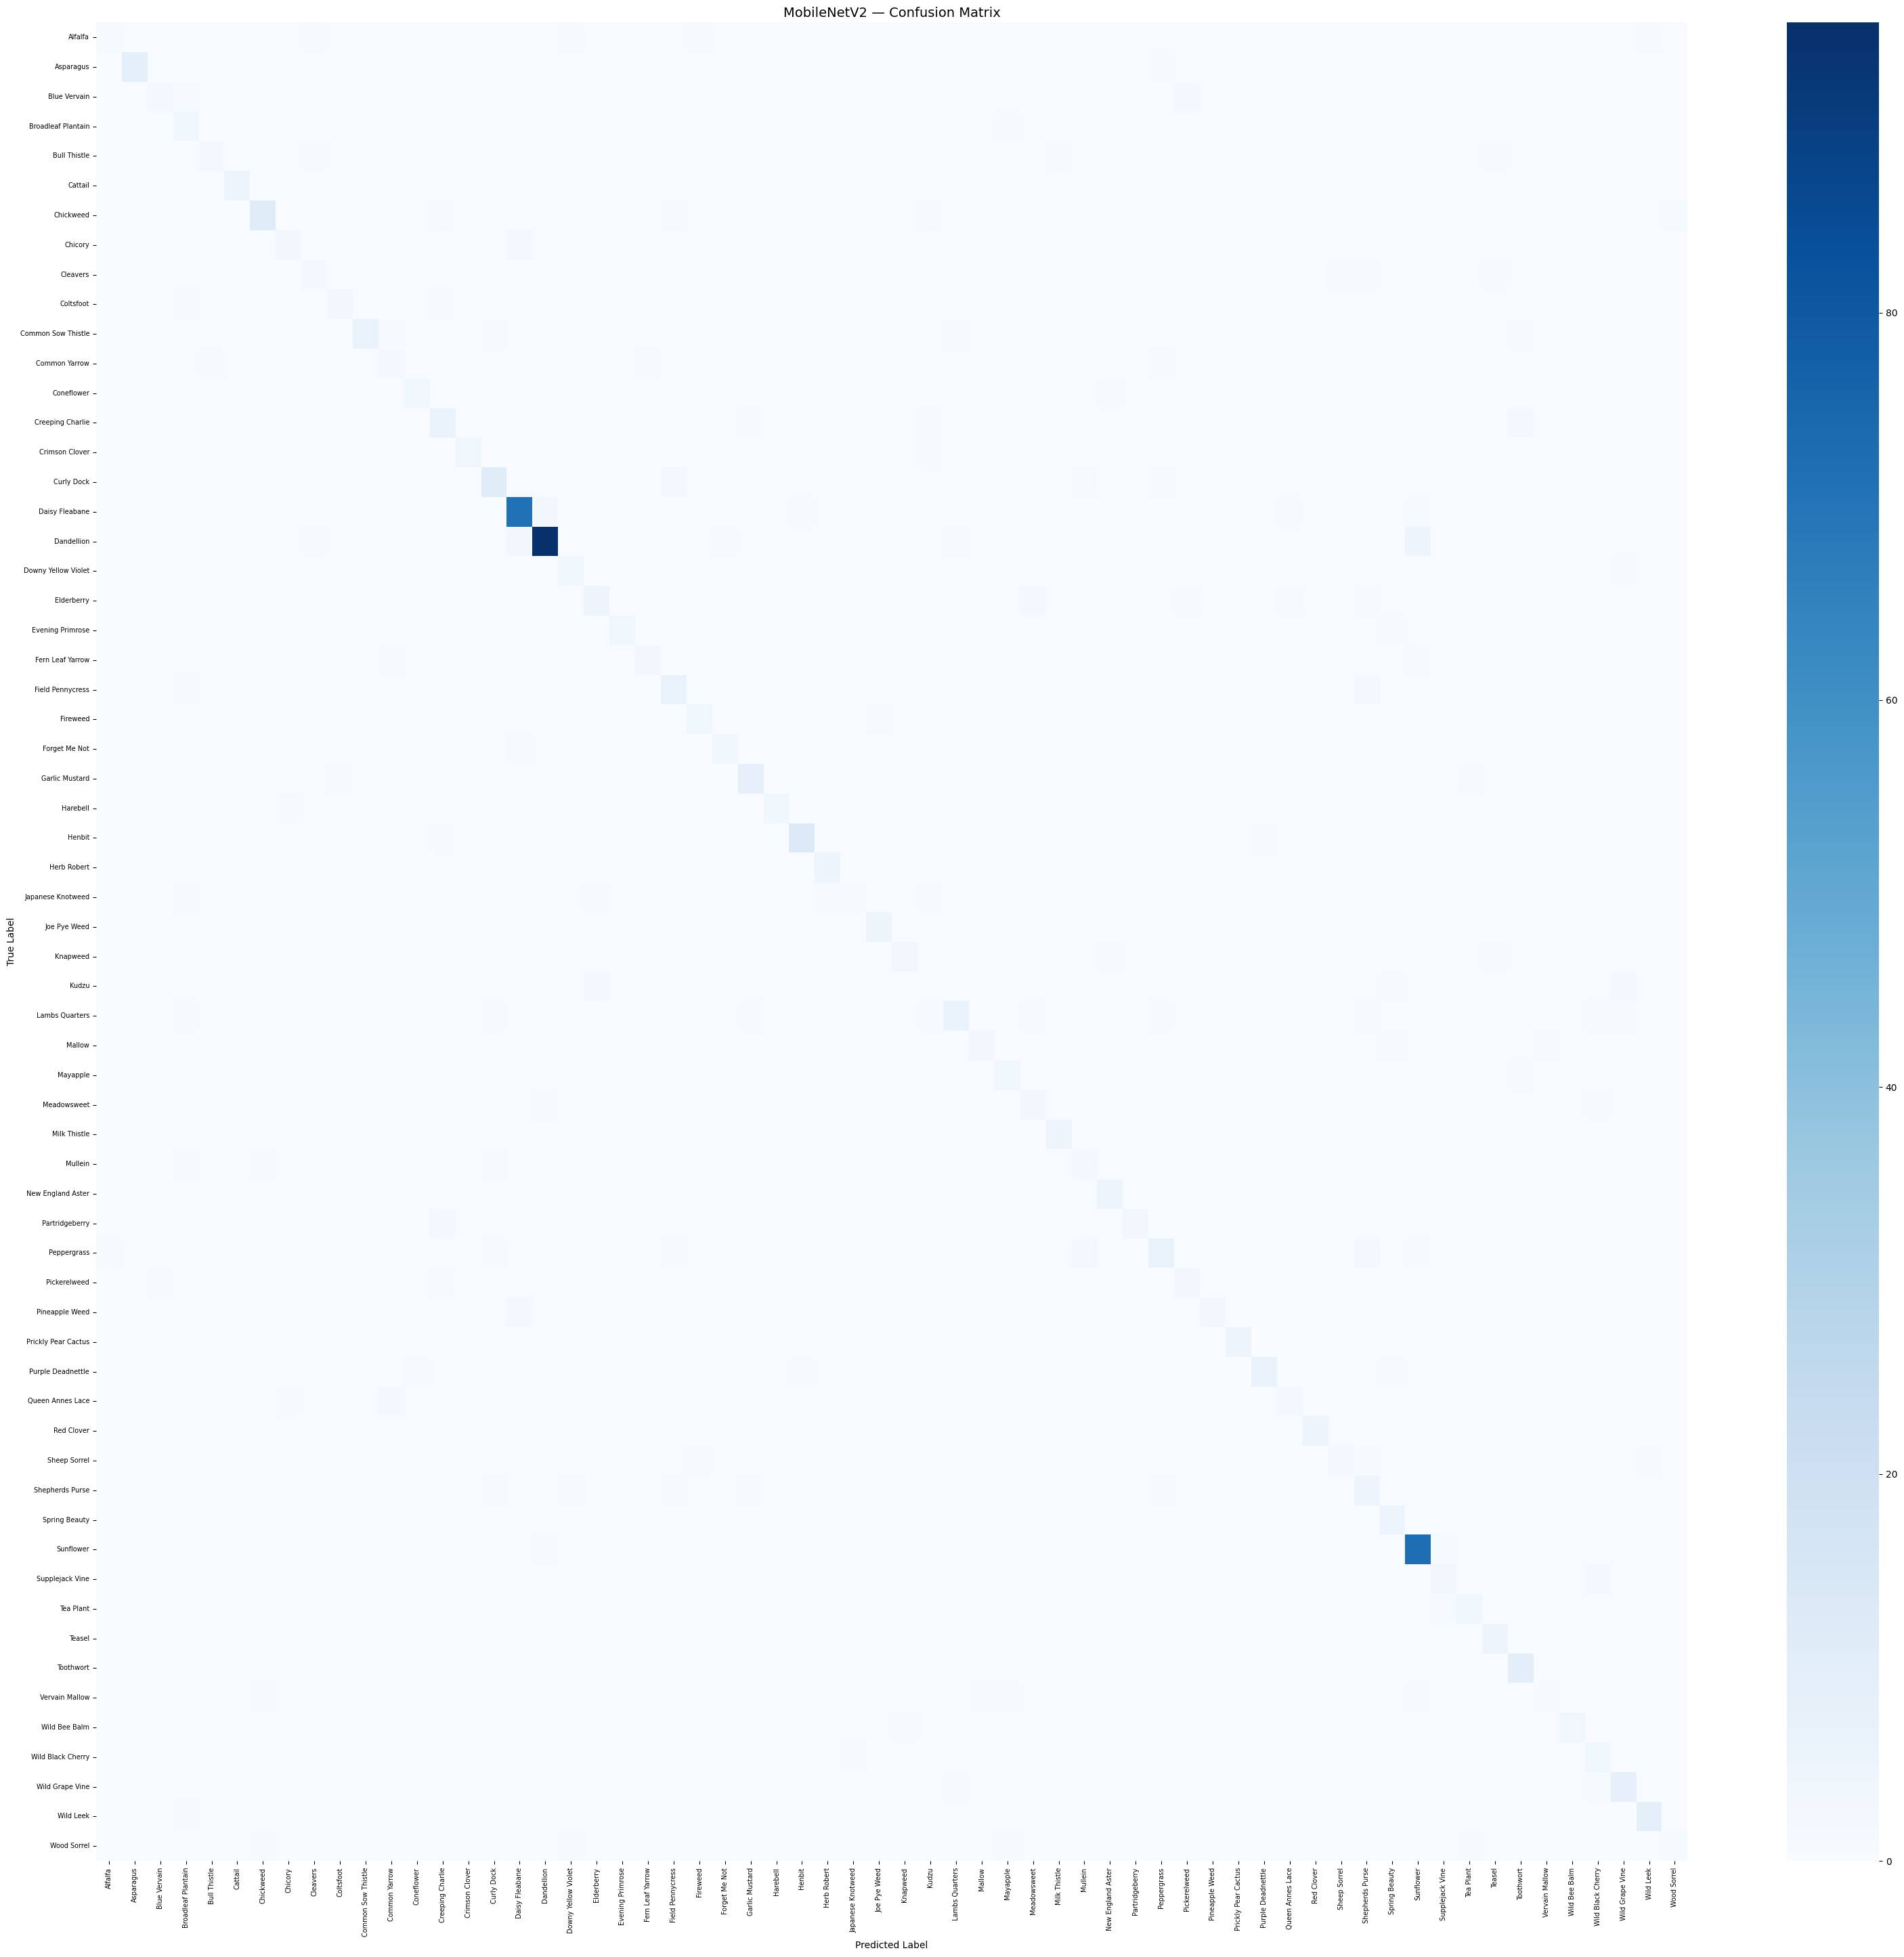

16524

In [ ]:
cm  = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
fsz = max(10, len(classes)//2)
plt.figure(figsize=(fsz, fsz-2))
sns.heatmap(cm, annot=(len(classes)<=20), fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('MobileNetV2 — Confusion Matrix', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()
del y_pred, y_true; gc.collect()

In [ ]:
model.save(FINAL_PATH)
print(f"Model saved: {FINAL_PATH}")
gc.collect(); tf.keras.backend.clear_session()

Model saved: /content/drive/MyDrive/edible_plants_models/MobileNetV2_edible_plants.keras


In [ ]:
# ── Upload ALL saved files to Google Drive ────────────────────────────────
# Uploads: phase1 checkpoint, phase2 checkpoint, final .keras model
# Works from LOCAL machine only. Skipped automatically on Colab.
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print("Running on Colab — all files already saved to Drive. Nothing to upload.")
else:
    print("Running locally — uploading all files from saved_models/ to Google Drive …")
    try:
        import subprocess as _sp, sys as _sys
        _sp.check_call([_sys.executable, '-m', 'pip', 'install', 'pydrive2', '-q'])

        from pydrive2.auth import GoogleAuth
        from pydrive2.drive import GoogleDrive

        # One-time browser login (cached after first run)
        gauth = GoogleAuth()
        gauth.LocalWebserverAuth()
        gdrive = GoogleDrive(gauth)

        # Find or create 'edible_plants_models' folder in Drive root
        folder_list = gdrive.ListFile(
            {'q': "title='edible_plants_models' and "
                  "mimeType='application/vnd.google-apps.folder' and "
                  "trashed=false"}
        ).GetList()

        if folder_list:
            folder_id = folder_list[0]['id']
            print(f"Found Drive folder  : edible_plants_models (id={folder_id})")
        else:
            folder = gdrive.CreateFile({
                'title': 'edible_plants_models',
                'mimeType': 'application/vnd.google-apps.folder'
            })
            folder.Upload()
            folder_id = folder['id']
            print(f"Created Drive folder: edible_plants_models (id={folder_id})")

        # Upload every file inside DRIVE_DIR (saved_models/)
        all_files = [f for f in os.listdir(DRIVE_DIR)
                     if os.path.isfile(os.path.join(DRIVE_DIR, f))]

        if not all_files:
            print("No files found in saved_models/ — make sure training completed.")
        else:
            print(f"\nUploading {len(all_files)} file(s):")
            for fname in sorted(all_files):
                local_path = os.path.join(DRIVE_DIR, fname)
                size_mb = os.path.getsize(local_path) / (1024 * 1024)

                # Check if file already exists in Drive folder → update it
                existing = gdrive.ListFile(
                    {'q': f"title='{fname}' and '{folder_id}' in parents and trashed=false"}
                ).GetList()

                if existing:
                    gfile = existing[0]
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Updated  {fname:50s}  ({size_mb:.1f} MB)")
                else:
                    gfile = gdrive.CreateFile({
                        'title': fname,
                        'parents': [{'id': folder_id}]
                    })
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Uploaded {fname:50s}  ({size_mb:.1f} MB)")

            print("\nAll files uploaded to Drive/edible_plants_models/")
            print("Open modelcomparison.ipynb on Colab to compare all models.")

    except Exception as e:
        print(f"Auto-upload failed: {e}")
        print("\nManual option:")
        print(f"  Go to drive.google.com → My Drive")
        print(f"  Create folder 'edible_plants_models' if it doesn't exist")
        print(f"  Upload all files from: {DRIVE_DIR}")

Running on Colab — all files already saved to Drive. Nothing to upload.


# EfficientNetB0 — Edible Plants (62 Classes)
> Works on **Google Colab** and **Local Jupyter** · Target ≥90%
> Models saved permanently — auto-uploaded to Drive from local

In [ ]:
import sys, os, gc, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Environment detection ─────────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IS_COLAB else 'Local (Jupyter)'}")
print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

Environment : Google Colab
TF version  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Storage setup (works on both Colab and Localhost) ─────────────────────
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR  = '/content/drive/MyDrive/edible_plants_models'
    DATA_ROOT  = '/content/plant_data'
else:
    # Local: save models in the project folder next to this notebook
    import pathlib
    PROJECT_DIR = str(pathlib.Path.cwd())
    DRIVE_DIR   = os.path.join(PROJECT_DIR, 'saved_models')
    DATA_ROOT   = os.path.join(PROJECT_DIR, 'plant_data')

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

print(f"Model save dir : {DRIVE_DIR}")
print(f"Data root      : {DATA_ROOT}")

Mounted at /content/drive
Model save dir : /content/drive/MyDrive/edible_plants_models
Data root      : /content/plant_data


In [ ]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

Using Colab cache for faster access to the 'edible-wild-plants' dataset.
Dataset path: /kaggle/input/edible-wild-plants


In [ ]:
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
if SOURCE_DIR is None:
    raise RuntimeError("Cannot find class root — re-run dataset download")

GOOD_FOLDERS = [d for d in sorted(os.listdir(SOURCE_DIR))
                if os.path.isdir(os.path.join(SOURCE_DIR, d))
                and any(f.lower().endswith(('.jpg','.jpeg','.png'))
                        for f in os.listdir(os.path.join(SOURCE_DIR, d)))]
print(f"SOURCE_DIR         : {SOURCE_DIR}")
print(f"Valid class folders: {len(GOOD_FOLDERS)}")

SOURCE_DIR         : /kaggle/input/edible-wild-plants/datasets/dataset
Valid class folders: 62


In [ ]:
# Only rebuild if train folder doesn't exist or is empty
if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
    if os.path.exists(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT)

    def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
        random.seed(seed); skipped = []
        for cls in classes:
            src = os.path.join(source, cls)
            imgs = [f for f in os.listdir(src)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                    and os.path.isfile(os.path.join(src, f))]
            if len(imgs) < 5: skipped.append(cls); continue
            random.shuffle(imgs)
            n_tr = int(len(imgs) * train_r)
            n_v  = max(int(len(imgs) * val_r), 1)
            for dest, flist in [
                (os.path.join(base,'train',cls), imgs[:n_tr]),
                (os.path.join(base,'val',  cls), imgs[n_tr:n_tr+n_v]),
                (os.path.join(base,'test', cls), imgs[n_tr+n_v:])
            ]:
                os.makedirs(dest, exist_ok=True)
                for f in flist:
                    shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
        return skipped

    print("Creating 80/10/10 split …")
    skipped = make_split(SOURCE_DIR, DATA_ROOT, GOOD_FOLDERS)
    if skipped: print(f"Skipped (too few images): {skipped}")
else:
    print("Split already exists — skipping rebuild.")

for split, d in [('train',TRAIN_DIR),('val',VAL_DIR),('test',TEST_DIR)]:
    if os.path.exists(d):
        nc = len([c for c in os.listdir(d) if os.path.isdir(os.path.join(d,c))])
        ni = sum(len(os.listdir(os.path.join(d,c)))
                 for c in os.listdir(d) if os.path.isdir(os.path.join(d,c)))
        print(f"  {split}: {nc} classes, {ni} images")

Creating 80/10/10 split …
  train: 62 classes, 5246 images
  val: 62 classes, 655 images
  test: 62 classes, 657 images


In [ ]:
IMG_SIZE = (224, 224); BATCH_SIZE = 8; SEED = 42
tf.keras.backend.clear_session(); gc.collect()
# EfficientNet has built-in rescaling — pass raw [0,255] pixels
train_gen = ImageDataGenerator(preprocessing_function=lambda x: x,
    rotation_range=30, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
vt_gen = ImageDataGenerator(preprocessing_function=lambda x: x)
train_ds = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
val_ds   = vt_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
test_ds  = vt_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
classes = list(train_ds.class_indices.keys()); NUM_CLASSES = len(classes)
STEPS    = max(int(np.ceil(train_ds.samples / BATCH_SIZE)), 1)
VAL_STP  = max(int(np.ceil(val_ds.samples   / BATCH_SIZE)), 1)
TEST_STP = max(int(np.ceil(test_ds.samples  / BATCH_SIZE)), 1)
print(f"Classes:{NUM_CLASSES}  Train:{train_ds.samples}  Val:{val_ds.samples}  Test:{test_ds.samples}")

Found 5246 images belonging to 62 classes.
Found 655 images belonging to 62 classes.
Found 657 images belonging to 62 classes.
Classes:62  Train:5246  Val:655  Test:657


In [ ]:
tf.keras.backend.clear_session(); gc.collect()
base_model = tf.keras.applications.EfficientNetB0(input_shape=(*IMG_SIZE,3),
    include_top=False, weights='imagenet')
base_model.trainable = False
inp = layers.Input(shape=(*IMG_SIZE,3))
x = base_model(inp, training=False)
x = layers.GlobalAveragePooling2D()(x); x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inp, out); model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,857,825 (18.53 MB)

 Trainable params: 805,694 (3.07 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
P1_CKPT    = os.path.join(DRIVE_DIR, 'EfficientNetB0_phase1_best.weights.h5')
FINAL_PATH = os.path.join(DRIVE_DIR, 'EfficientNetB0_edible_plants.keras')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p1 = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-7, verbose=1),
         ModelCheckpoint(P1_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 1 checkpoint -> {P1_CKPT}")
print("=== Phase 1: Head training (base FROZEN) ===")
h1 = model.fit(train_ds, epochs=30, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p1, verbose=1)
print(f"Phase 1 best val_accuracy: {max(h1.history['val_accuracy']):.4f}")
gc.collect()

Phase 1 checkpoint -> /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase1_best.weights.h5
=== Phase 1: Head training (base FROZEN) ===
Epoch 1/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3015 - auc: 0.8068 - loss: 3.4049 - precision: 0.7466 - recall: 0.1821
Epoch 1: val_accuracy improved from None to 0.52519, saving model to /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase1_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 174s 200ms/step - accuracy: 0.3673 - auc: 0.8557 - loss: 3.0925 - precision: 0.8173 - recall: 0.2286 - val_accuracy: 0.5252 - val_auc: 0.9542 - val_loss: 2.3518 - val_precision: 0.8725 - val_recall: 0.3969 - learning_rate: 0.0010
Epoch 2/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4411 - auc: 0.9161 - loss: 2.7202 - precision: 0.8054 - recall: 0.2799
Epoch 2: val_accuracy improved from 0.52519 to

2268

In [ ]:
P2_CKPT = os.path.join(DRIVE_DIR, 'EfficientNetB0_phase2_best.weights.h5')
model.load_weights(P1_CKPT)
base_model.trainable = True
# Keep ALL BN layers frozen — critical for EfficientNet stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False
for layer in base_model.layers[:-50]: layer.trainable = False
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=max(STEPS*40,1), alpha=1e-7)
model.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p2 = [EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
         ModelCheckpoint(P2_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 2 checkpoint -> {P2_CKPT}")
print("=== Phase 2: Fine-tuning top-50 base layers ===")
gc.collect()
h2 = model.fit(train_ds, epochs=10, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p2, verbose=1)
print(f"Phase 2 best val_accuracy: {max(h2.history['val_accuracy']):.4f}")
gc.collect()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 63 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Phase 2 checkpoint -> /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase2_best.weights.h5
=== Phase 2: Fine-tuning top-50 base layers ===
Epoch 1/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8121 - auc: 0.9948 - loss: 1.2650 - precision: 0.9377 - recall: 0.6784
Epoch 1: val_accuracy improved from None to 0.80458, saving model to /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/EfficientNetB0_phase2_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 147s 182ms/step - accuracy: 0.8115 - auc: 0.9944 - loss: 1.2711 - precision: 0.9293 - recall: 0.6895 - val_accuracy: 0.8046 - val_auc: 0.9882 - val_loss: 1.3108 - val_precision: 0.8915 - val_recall: 0.7405
Epoch 2/10
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8393 - auc: 0.9950 - loss: 1.2003 - precision: 0.9379 - recall: 0.7244
Epoch 2: val_accuracy improved from 0.80458 to 0.82443, saving mode

1843

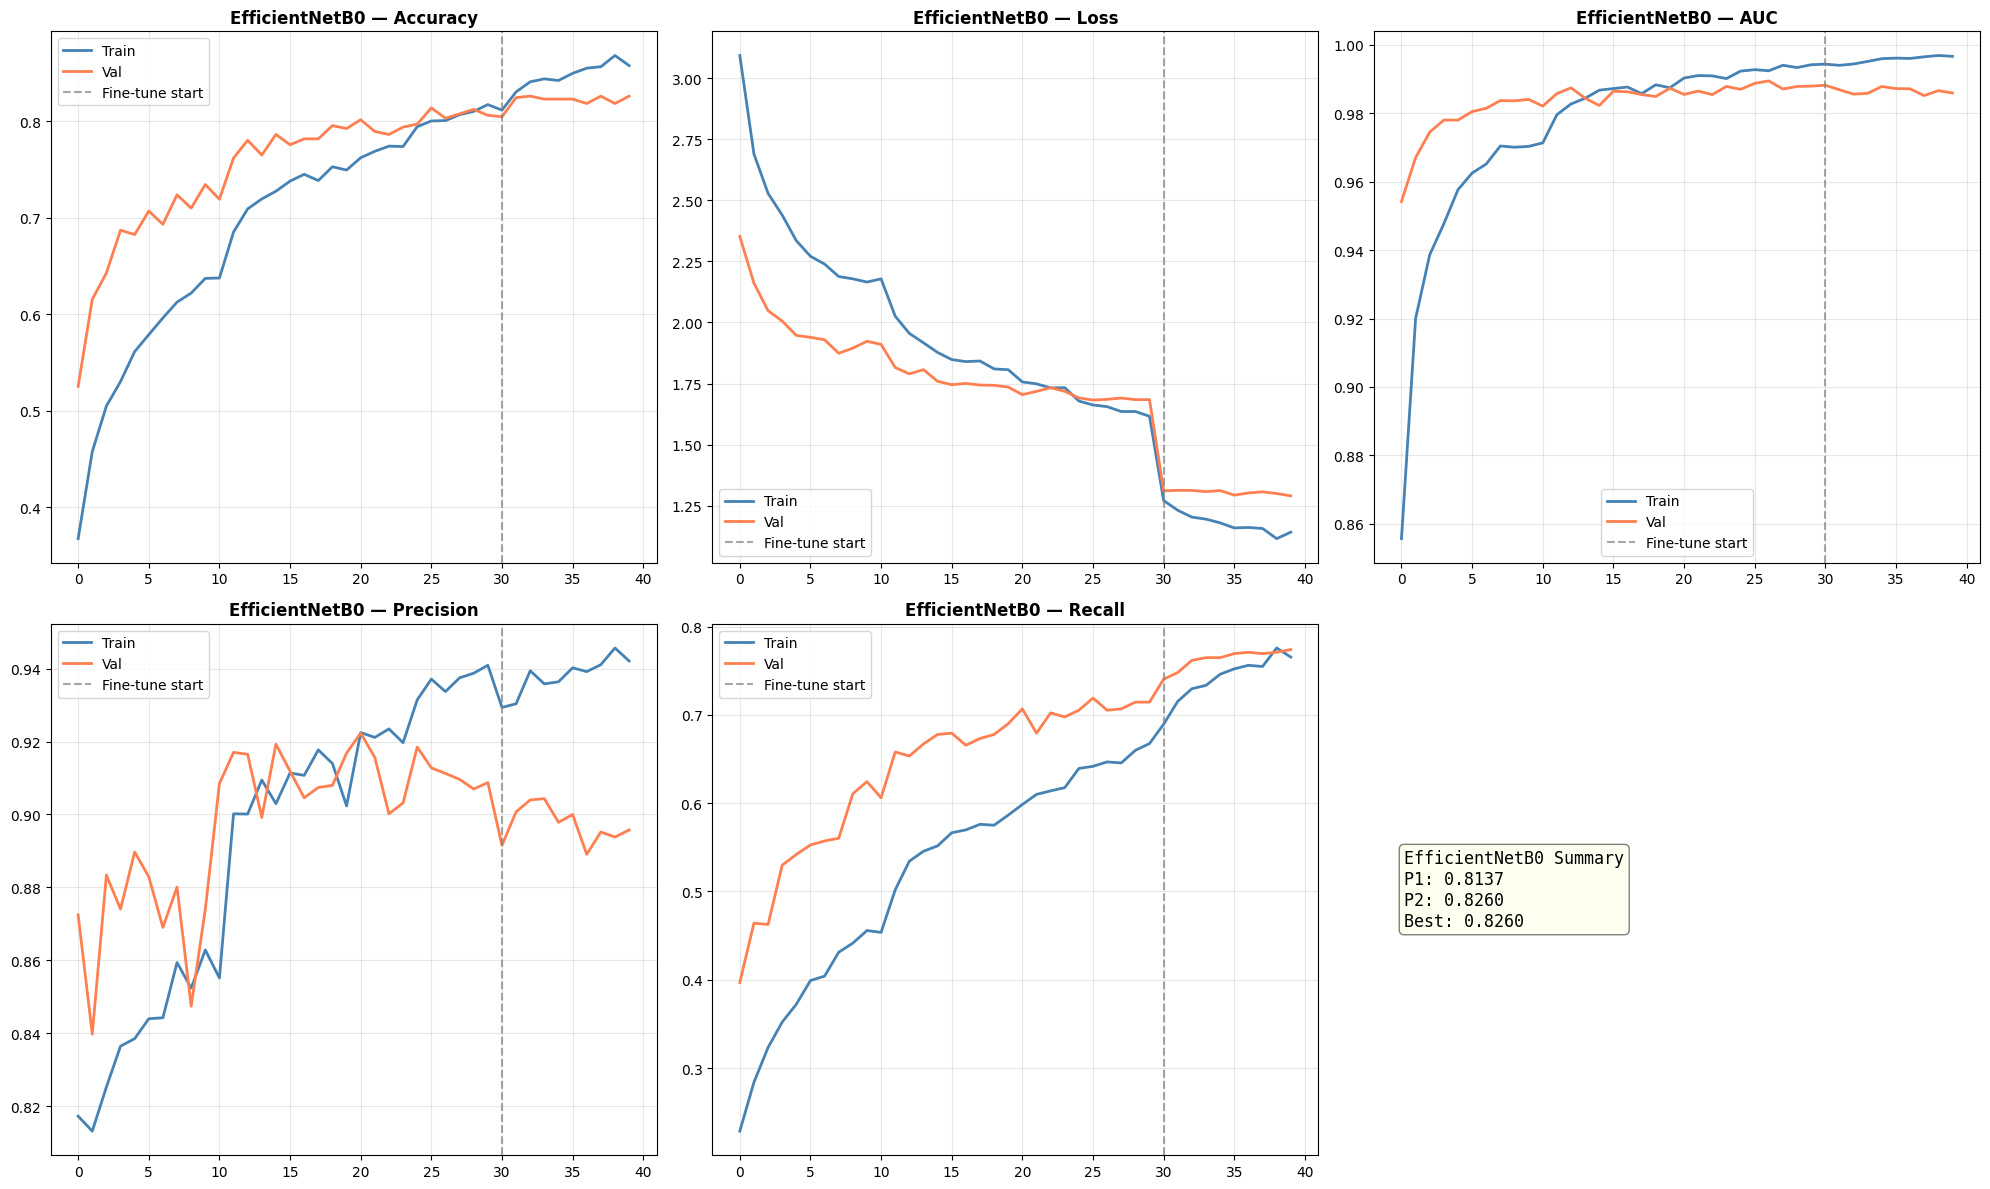

In [ ]:
def combine(h1, h2, key): return h1.history.get(key,[]) + h2.history.get(key,[])
phase1_end = len(h1.history['accuracy'])
pairs = [('accuracy','val_accuracy','Accuracy'),('loss','val_loss','Loss'),
         ('auc','val_auc','AUC'),('precision','val_precision','Precision'),('recall','val_recall','Recall')]
fig, axes = plt.subplots(2, 3, figsize=(20,12))
for ax,(tr,vl,title) in zip(axes.flat, pairs):
    ax.plot(combine(h1,h2,tr), color='steelblue', lw=2, label='Train')
    ax.plot(combine(h1,h2,vl), color='coral',     lw=2, label='Val')
    ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(f'EfficientNetB0 — {title}', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
ax_s = axes.flat[-1]; ax_s.axis('off')
ax_s.text(0.05,0.5, f"EfficientNetB0 Summary\nP1: {max(h1.history['val_accuracy']):.4f}\nP2: {max(h2.history['val_accuracy']):.4f}\nBest: {max(combine(h1,h2,'val_accuracy')):.4f}",
    fontsize=12,family='monospace',verticalalignment='center',
    bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.5))
plt.tight_layout(); plt.show()

In [ ]:
print("Running streaming predictions on test set …")
y_pred_list = []; y_true_list = []
test_ds.reset()
for batch_x, batch_y in test_ds:
    preds = model.predict_on_batch(batch_x)
    y_pred_list.append(np.argmax(preds,   axis=1))
    y_true_list.append(np.argmax(batch_y, axis=1))
    if len(y_pred_list) >= TEST_STP: break
y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
del y_pred_list, y_true_list; gc.collect()
n = min(len(y_pred), len(y_true)); y_pred, y_true = y_pred[:n], y_true[:n]

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Grade     : {'EXCELLENT (>=90%)' if acc>=0.90 else 'GOOD (>=80%)' if acc>=0.80 else 'Needs tuning'}")
print("\n—— Classification Report ——")
print(classification_report(y_true, y_pred, labels=np.arange(len(classes)),
                             target_names=classes, zero_division=0))

Running streaming predictions on test set …

  Accuracy  : 0.7945
  Precision : 0.8084
  Recall    : 0.7945
  F1-Score  : 0.7909
  Grade     : Needs tuning

—— Classification Report ——
                     precision    recall  f1-score   support

            Alfalfa       0.67      0.40      0.50         5
          Asparagus       0.89      0.80      0.84        10
       Blue Vervain       1.00      1.00      1.00         5
 Broadleaf Plantain       0.43      0.60      0.50         5
       Bull Thistle       0.60      0.60      0.60         5
            Cattail       0.50      1.00      0.67         5
          Chickweed       0.73      0.73      0.73        15
            Chicory       1.00      1.00      1.00         5
           Cleavers       0.56      1.00      0.71         5
          Coltsfoot       0.67      0.80      0.73         5
 Common Sow Thistle       1.00      0.80      0.89        10
      Common Yarrow       0.33      0.20      0.25         5
         Coneflower  

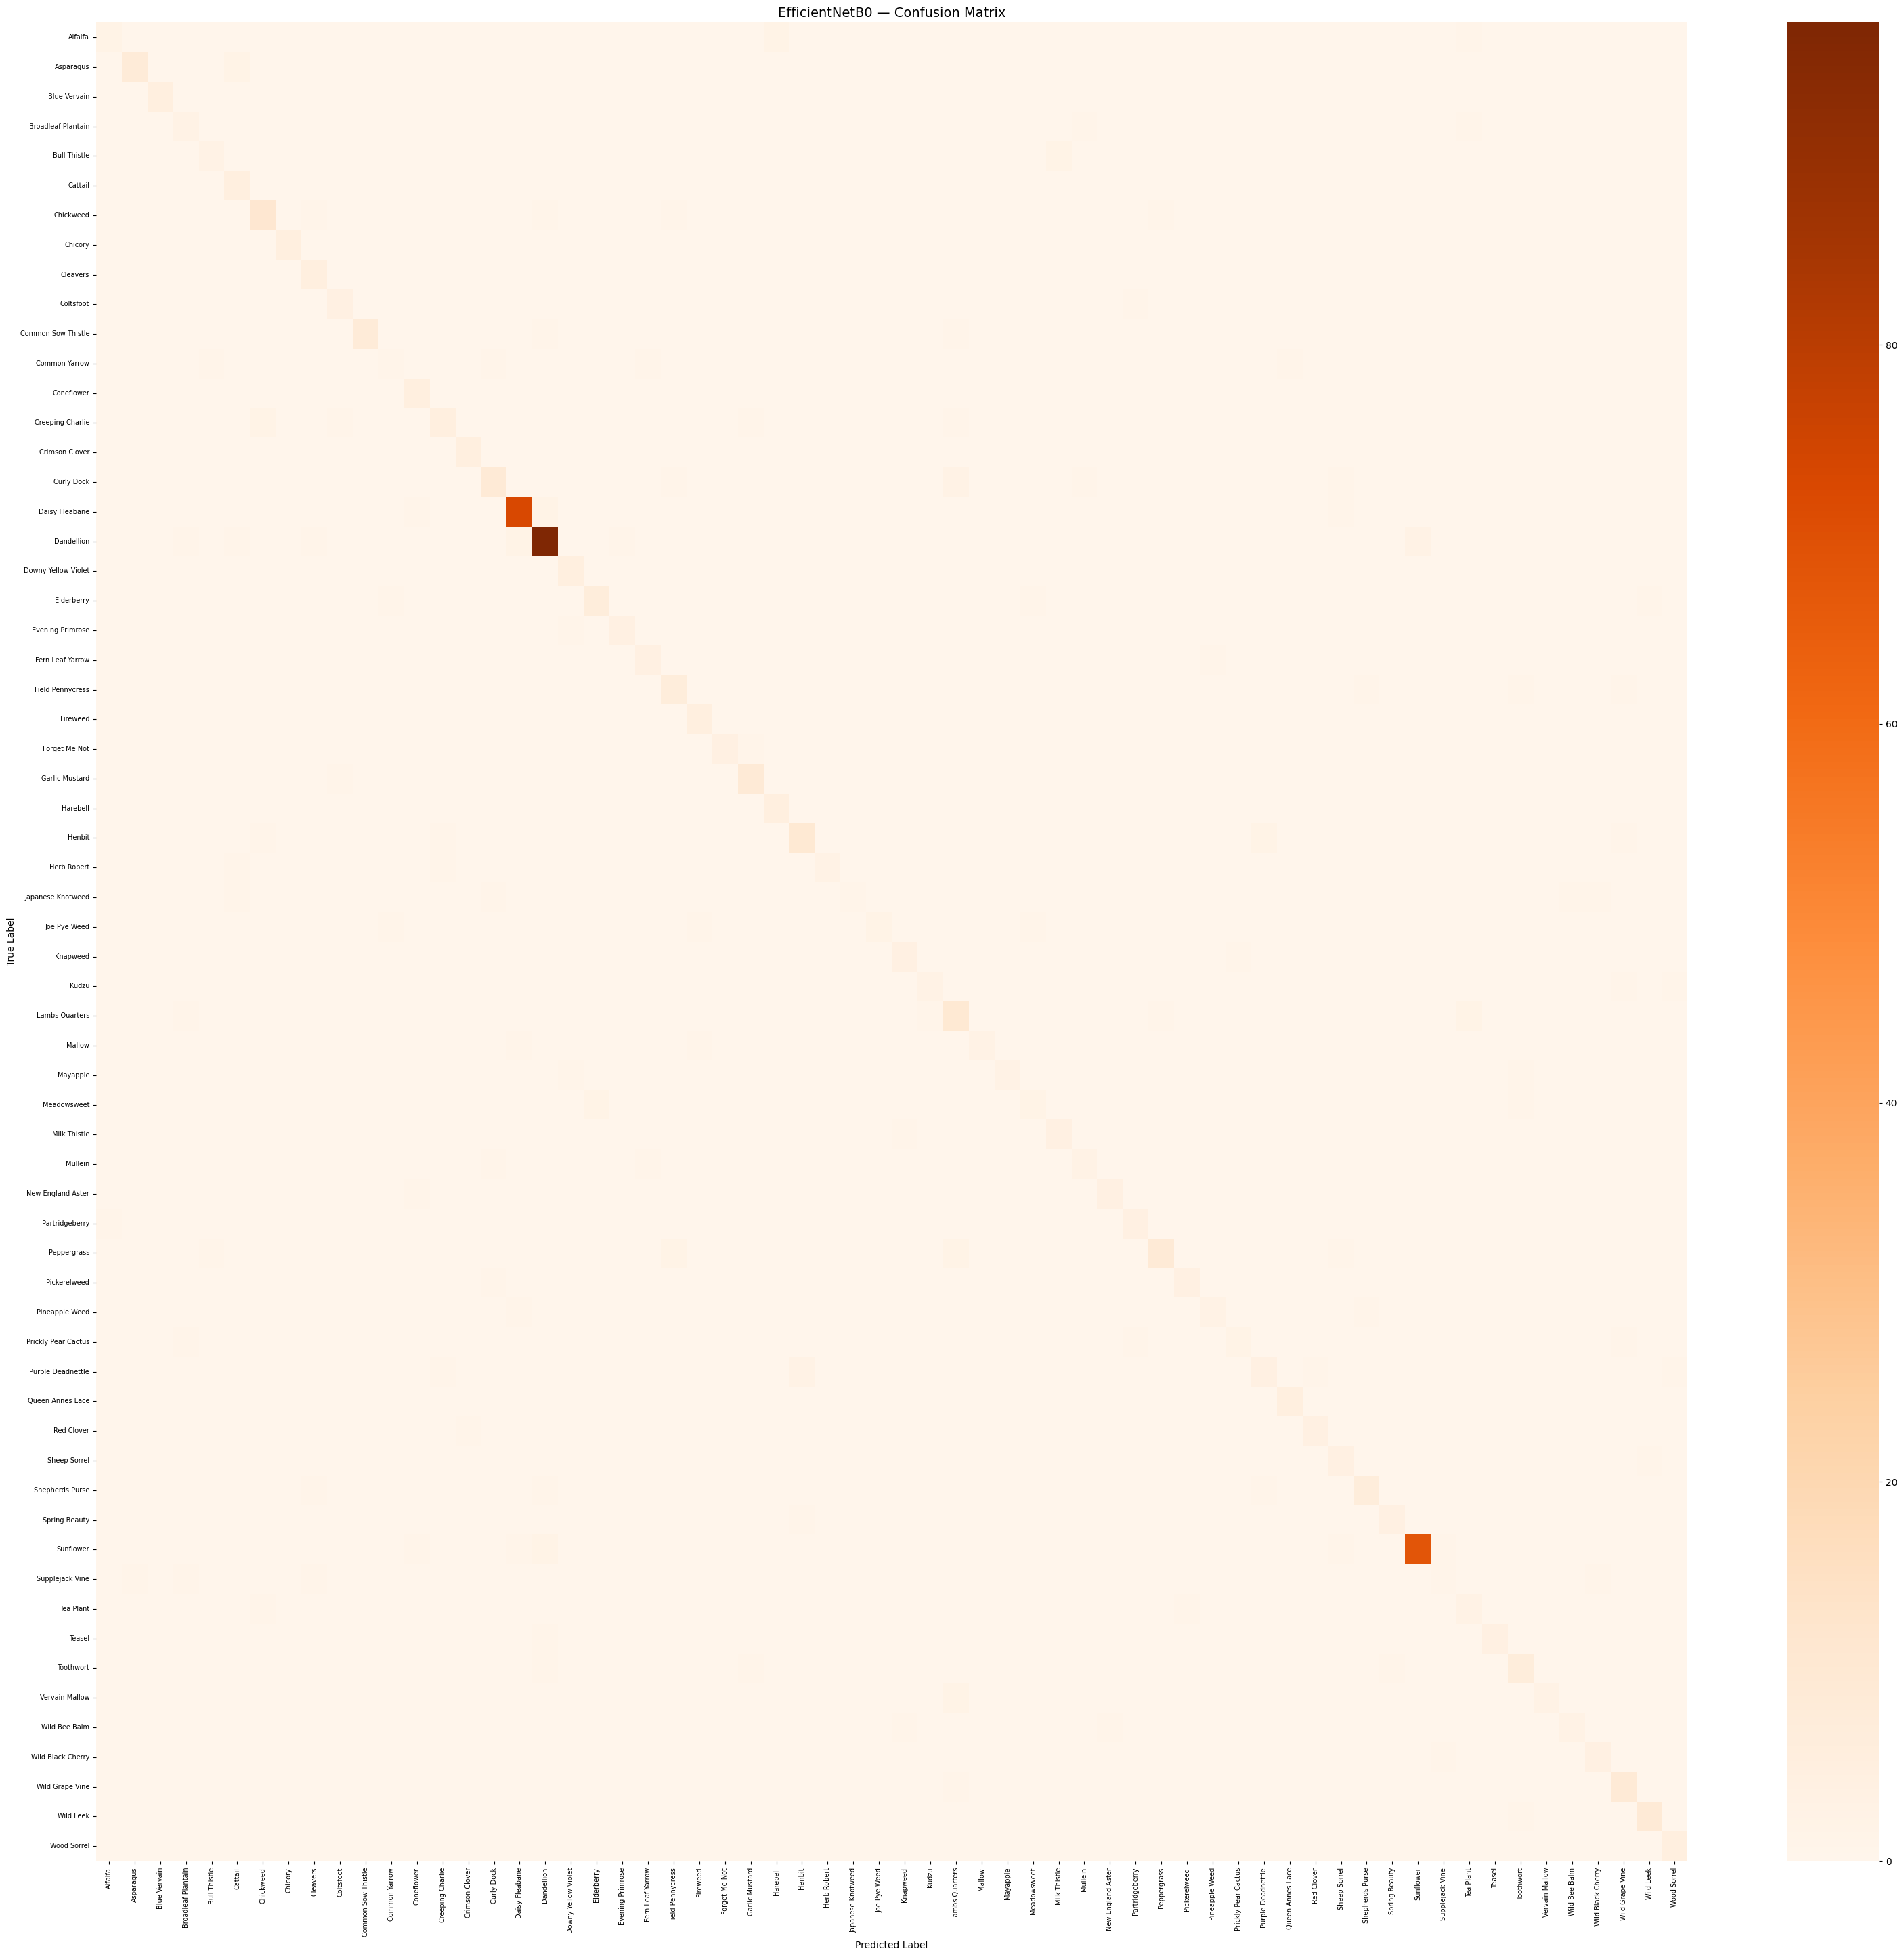

16524

In [ ]:
cm  = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
fsz = max(10, len(classes)//2)
plt.figure(figsize=(fsz, fsz-2))
sns.heatmap(cm, annot=(len(classes)<=20), fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Oranges')
plt.title('EfficientNetB0 — Confusion Matrix', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()
del y_pred, y_true; gc.collect()

In [ ]:
model.save(FINAL_PATH)
print(f"Model saved: {FINAL_PATH}")
gc.collect(); tf.keras.backend.clear_session()

Model saved: /content/drive/MyDrive/edible_plants_models/EfficientNetB0_edible_plants.keras


In [ ]:
# ── Upload ALL saved files to Google Drive ────────────────────────────────
# Uploads: phase1 checkpoint, phase2 checkpoint, final .keras model
# Works from LOCAL machine only. Skipped automatically on Colab.
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print("Running on Colab — all files already saved to Drive. Nothing to upload.")
else:
    print("Running locally — uploading all files from saved_models/ to Google Drive …")
    try:
        import subprocess as _sp, sys as _sys
        _sp.check_call([_sys.executable, '-m', 'pip', 'install', 'pydrive2', '-q'])

        from pydrive2.auth import GoogleAuth
        from pydrive2.drive import GoogleDrive

        # One-time browser login (cached after first run)
        gauth = GoogleAuth()
        gauth.LocalWebserverAuth()
        gdrive = GoogleDrive(gauth)

        # Find or create 'edible_plants_models' folder in Drive root
        folder_list = gdrive.ListFile(
            {'q': "title='edible_plants_models' and "
                  "mimeType='application/vnd.google-apps.folder' and "
                  "trashed=false"}
        ).GetList()

        if folder_list:
            folder_id = folder_list[0]['id']
            print(f"Found Drive folder  : edible_plants_models (id={folder_id})")
        else:
            folder = gdrive.CreateFile({
                'title': 'edible_plants_models',
                'mimeType': 'application/vnd.google-apps.folder'
            })
            folder.Upload()
            folder_id = folder['id']
            print(f"Created Drive folder: edible_plants_models (id={folder_id})")

        # Upload every file inside DRIVE_DIR (saved_models/)
        all_files = [f for f in os.listdir(DRIVE_DIR)
                     if os.path.isfile(os.path.join(DRIVE_DIR, f))]

        if not all_files:
            print("No files found in saved_models/ — make sure training completed.")
        else:
            print(f"\nUploading {len(all_files)} file(s):")
            for fname in sorted(all_files):
                local_path = os.path.join(DRIVE_DIR, fname)
                size_mb = os.path.getsize(local_path) / (1024 * 1024)

                # Check if file already exists in Drive folder → update it
                existing = gdrive.ListFile(
                    {'q': f"title='{fname}' and '{folder_id}' in parents and trashed=false"}
                ).GetList()

                if existing:
                    gfile = existing[0]
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Updated  {fname:50s}  ({size_mb:.1f} MB)")
                else:
                    gfile = gdrive.CreateFile({
                        'title': fname,
                        'parents': [{'id': folder_id}]
                    })
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Uploaded {fname:50s}  ({size_mb:.1f} MB)")

            print("\nAll files uploaded to Drive/edible_plants_models/")
            print("Open modelcomparison.ipynb on Colab to compare all models.")

    except Exception as e:
        print(f"Auto-upload failed: {e}")
        print("\nManual option:")
        print(f"  Go to drive.google.com → My Drive")
        print(f"  Create folder 'edible_plants_models' if it doesn't exist")
        print(f"  Upload all files from: {DRIVE_DIR}")

Running on Colab — all files already saved to Drive. Nothing to upload.


# Model Comparison — Edible Plants (62 Classes)
> Loads all 4 trained models (from **this account's Drive** OR **manually uploaded**)  
> and compares Accuracy · Precision · Recall · F1-Score

In [ ]:
import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: []


In [ ]:
# Mount this account's Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/edible_plants_models'
os.makedirs(DRIVE_DIR, exist_ok=True)

# ── Expected model file names (same names each training notebook saves) ──
MODEL_FILES = {
    "CNN"          : "CustomCNN_edible_plants.keras",
    "ResNet50"     : "ResNet50_edible_plants.keras",
    "MobileNetV2"  : "MobileNetV2_edible_plants.keras",
    "EfficientNetB0": "EfficientNetB0_edible_plants.keras",
}

print("\nChecking Drive for saved models:")
print(f"Drive folder: {DRIVE_DIR}\n")
for name, fname in MODEL_FILES.items():
    full = os.path.join(DRIVE_DIR, fname)
    status = "FOUND   ✓" if os.path.exists(full) else "MISSING ✗"
    print(f"  [{status}]  {name:16s}  {fname}")

Mounted at /content/drive

Checking Drive for saved models:
Drive folder: /content/drive/MyDrive/edible_plants_models

  [FOUND   ✓]  CNN               CustomCNN_edible_plants.keras
  [FOUND   ✓]  ResNet50          ResNet50_edible_plants.keras
  [FOUND   ✓]  MobileNetV2       MobileNetV2_edible_plants.keras
  [FOUND   ✓]  EfficientNetB0    EfficientNetB0_edible_plants.keras


In [ ]:
from google.colab import files as colab_files

print("Upload .keras files from other Gmail accounts (skip if all FOUND above):")
print("Press the button below — you can select multiple files at once.")

uploaded = colab_files.upload()   # opens file picker

if uploaded:
    for fname, data in uploaded.items():
        dest = os.path.join(DRIVE_DIR, fname)
        with open(dest, 'wb') as f:
            f.write(data)
        print(f"  Saved to Drive: {dest}")
    print("\nRe-checking Drive after upload:")
    for name, fname in MODEL_FILES.items():
        full = os.path.join(DRIVE_DIR, fname)
        status = "FOUND   ✓" if os.path.exists(full) else "MISSING ✗"
        print(f"  [{status}]  {name:16s}  {fname}")
else:
    print("No files uploaded — continuing with models already in Drive.")

Upload .keras files from other Gmail accounts (skip if all FOUND above):
Press the button below — you can select multiple files at once.


Saving download.jpg to download (2).jpg
  Saved to Drive: /content/drive/MyDrive/edible_plants_models/download (2).jpg

Re-checking Drive after upload:
  [FOUND   ✓]  CNN               CustomCNN_edible_plants.keras
  [FOUND   ✓]  ResNet50          ResNet50_edible_plants.keras
  [FOUND   ✓]  MobileNetV2       MobileNetV2_edible_plants.keras
  [FOUND   ✓]  EfficientNetB0    EfficientNetB0_edible_plants.keras


In [ ]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
print("SOURCE_DIR:", SOURCE_DIR)
print("Classes:", len([d for d in os.listdir(SOURCE_DIR)
                        if os.path.isdir(os.path.join(SOURCE_DIR, d))]))

100%|██████████| 766M/766M [00:05<00:00, 148MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5
SOURCE_DIR: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5/datasets/dataset
Classes: 62


In [ ]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 8

# Use 20% validation split as held-out test proxy
# (matches the val subset used if training notebooks used full SOURCE_DIR)
test_gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_ds = test_gen.flow_from_directory(
    SOURCE_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=42, shuffle=False)

classes  = list(test_ds.class_indices.keys())
TEST_STP = max(int(np.ceil(test_ds.samples / BATCH_SIZE)), 1)

print(f"Test samples : {test_ds.samples}")
print(f"Classes      : {len(classes)}")
print(f"Test steps   : {TEST_STP}")

Found 1311 images belonging to 62 classes.
Test samples : 1311
Classes      : 62
Test steps   : 164


In [ ]:
# Load all available models from Drive
models_loaded = {}

for name, fname in MODEL_FILES.items():
    path_to_model = os.path.join(DRIVE_DIR, fname)
    if os.path.exists(path_to_model):
        try:
            m = tf.keras.models.load_model(path_to_model)
            models_loaded[name] = m
            print(f"  Loaded  {name}")
        except Exception as e:
            print(f"  ERROR loading {name}: {e}")
    else:
        print(f"  SKIP    {name} — file not in Drive yet")
        print(f"          Train it and upload: {fname}")

print(f"\nReady to compare: {list(models_loaded.keys())}")
gc.collect()

  Loaded  CNN
  Loaded  ResNet50
  Loaded  MobileNetV2
  Loaded  EfficientNetB0

Ready to compare: ['CNN', 'ResNet50', 'MobileNetV2', 'EfficientNetB0']


264

In [ ]:
# Evaluate each model with streaming predictions (RAM-safe)
def evaluate_model(model, name):
    test_ds.reset()
    y_pred_list = []; y_true_list = []

    # Get expected input height/width from the model
    # Many Keras models have it at model.input_shape[1:3]
    try:
        target_h, target_w = model.input_shape[1], model.input_shape[2]
    except:
        target_h, target_w = 224, 224 # Fallback

    for batch_x, batch_y in test_ds:
        # Resize batch if it doesn't match model expectations
        if batch_x.shape[1] != target_h or batch_x.shape[2] != target_w:
            batch_x = tf.image.resize(batch_x, (target_h, target_w)).numpy()

        preds = model.predict_on_batch(batch_x)
        y_pred_list.append(np.argmax(preds,   axis=1))
        y_true_list.append(np.argmax(batch_y, axis=1))
        if len(y_pred_list) >= TEST_STP: break

    y_pred = np.concatenate(y_pred_list)
    y_true = np.concatenate(y_true_list)
    del y_pred_list, y_true_list; gc.collect()

    n = min(len(y_pred), len(y_true))
    y_pred, y_true = y_pred[:n], y_true[:n]

    return {
        "Model"    : name,
        "Accuracy" : accuracy_score (y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall"   : recall_score   (y_true, y_pred, average='weighted', zero_division=0),
        "F1-Score" : f1_score       (y_true, y_pred, average='weighted', zero_division=0),
    }

results = []
if not models_loaded:
    print("No models loaded. Train notebooks first and upload .keras files above.")
else:
    for name, model in models_loaded.items():
        print(f"Evaluating {name} …", end=' ')
        try:
            res = evaluate_model(model, name)
            results.append(res)
            print(f"Accuracy: {res['Accuracy']:.4f}  F1: {res['F1-Score']:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")

        # Cleanup to save RAM
        # We don't delete from models_loaded yet as user might want samples
        # but we clear the backend session
        tf.keras.backend.clear_session(); gc.collect()

    df = (pd.DataFrame(results)
            .sort_values('Accuracy', ascending=False)
            .reset_index(drop=True))
    print("\n### MODEL PERFORMANCE COMPARISON ###")
    print(df.to_string(index=False))

Evaluating CNN … Accuracy: 0.4104  F1: 0.3628
Evaluating ResNet50 … Accuracy: 0.8413  F1: 0.8381
Evaluating MobileNetV2 … Accuracy: 0.8215  F1: 0.8203
Evaluating EfficientNetB0 … Accuracy: 0.1602  F1: 0.0442

### MODEL PERFORMANCE COMPARISON ###
         Model  Accuracy  Precision   Recall  F1-Score
      ResNet50  0.841342   0.853069 0.841342  0.838113
   MobileNetV2  0.821510   0.840183 0.821510  0.820288
           CNN  0.410374   0.406746 0.410374  0.362831
EfficientNetB0  0.160183   0.025659 0.160183  0.044232


### Model Performance Tabular Summary (Testing)

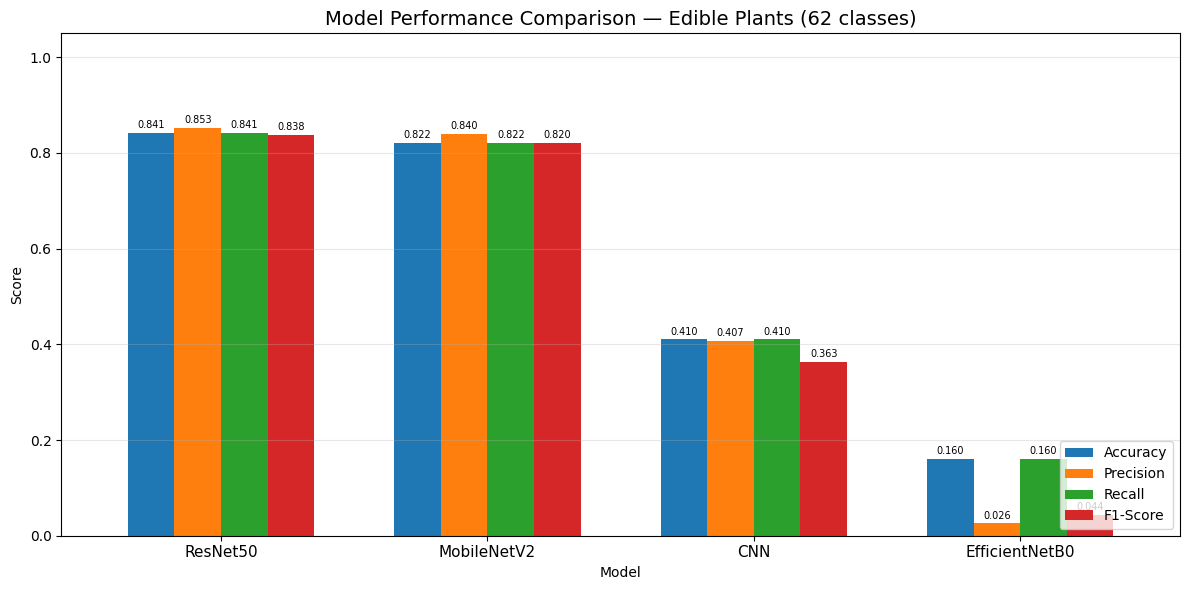

In [ ]:
if results:
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    ax = df.set_index('Model')[metrics].plot(kind='bar', figsize=(12, 6), width=0.7)
    plt.title('Model Performance Comparison — Edible Plants (62 classes)', fontsize=14)
    plt.xticks(rotation=0, fontsize=11); plt.ylim(0, 1.05)
    plt.ylabel('Score'); plt.grid(axis='y', alpha=0.3); plt.legend(loc='lower right')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
    plt.tight_layout(); plt.show()
else:
    print("No results to plot — run evaluation cell first.")

### Model Performance Bar Chart (Testing)

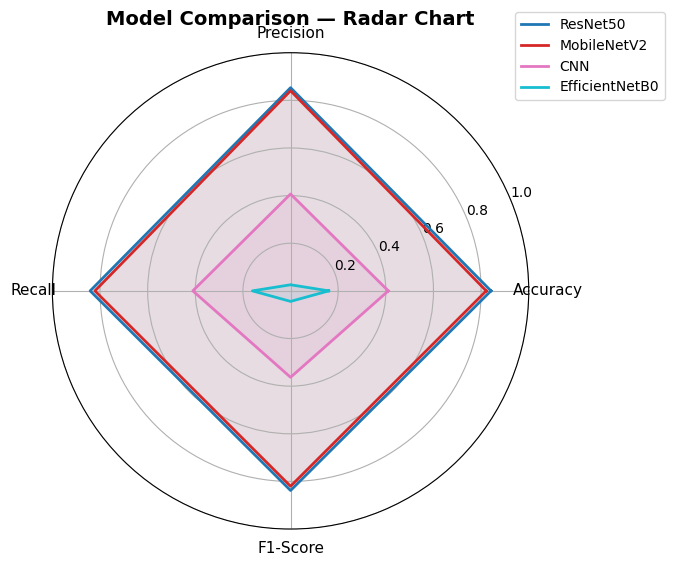

In [ ]:
if results:
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    for i, row in df.iterrows():
        vals = [row[m] for m in metrics] + [row[metrics[0]]]
        ax.plot(angles, vals, lw=2, color=colors[i], label=row['Model'])
        ax.fill(angles, vals, alpha=0.1, color=colors[i])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_title('Model Comparison — Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout(); plt.show()

### Model Comparison Radar Chart (Testing)

In [ ]:
if results:
    best = df.iloc[0]
    print("\n" + "="*50)
    print("  BEST MODEL")
    print("="*50)
    for col in df.columns:
        val = best[col]
        print(f"  {col:<12}: {val:.4f}" if isinstance(val, float) else f"  {col:<12}: {val}")
    grade = ("EXCELLENT (>=90%)" if best['Accuracy'] >= 0.90
             else "GOOD (>=80%)"  if best['Accuracy'] >= 0.80
             else "Needs more training")
    print(f"  {'Grade':<12}: {grade}")
    print("="*50)
else:
    print("No models evaluated yet.")


  BEST MODEL
  Model       : ResNet50
  Accuracy    : 0.8413
  Precision   : 0.8531
  Recall      : 0.8413
  F1-Score    : 0.8381
  Grade       : GOOD (>=80%)


### Visualizing Model Predictions
This section picks random samples from the test set and shows the prediction from each loaded model.

In [ ]:
def show_model_samples(model, name, test_dataset, num_samples=4):
    test_dataset.reset()
    x_batch, y_batch = next(test_dataset)
    indices = random.sample(range(len(x_batch)), min(num_samples, len(x_batch)))

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Sample Predictions: {name}", fontsize=16)
    for i, idx in enumerate(indices):
        img = x_batch[idx]
        true_label = classes[np.argmax(y_batch[idx])]
        pred_probs = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_label = classes[np.argmax(pred_probs)]
        color = 'green' if true_label == pred_label else 'red'
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Individual cells for each model follows below...

### Custom Image Inference
Upload an image of your choice to see how each model classifies it.

Upload an image (Edible or Non-Edible plant):


Saving download.jpg to download (3).jpg


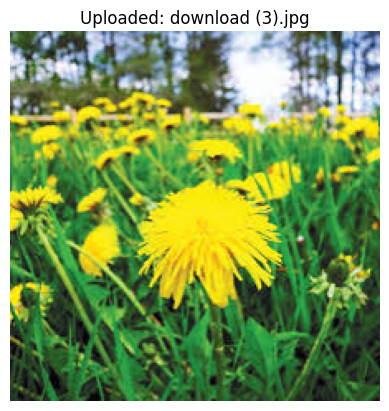

In [ ]:
from google.colab import files
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Fallback if previous cells weren't run
if 'IMG_SIZE' not in globals():
    IMG_SIZE = (224, 224)

print("Upload an image (Edible or Non-Edible plant):")
uploaded_img = files.upload()

custom_img_path = None
img_batch = None

if uploaded_img:
    custom_img_path = list(uploaded_img.keys())[0]
    # Preprocess for the models
    img_raw = Image.open(custom_img_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img_raw) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    plt.imshow(img_raw)
    plt.title(f"Uploaded: {custom_img_path}")
    plt.axis('off')
    plt.show()
else:
    print("No image uploaded.")

#### Individual Model Predictions

In [ ]:
custom_results = {}

def predict_and_show(name):
    # Access global variables explicitly
    m_loaded = globals().get('models_loaded', {})
    batch = globals().get('img_batch', None)
    cls_list = globals().get('classes', [])

    if name in m_loaded and batch is not None and len(cls_list) > 0:
        model = m_loaded[name]

        # Check if the model needs a different image size than the uploaded batch
        try:
            target_h, target_w = model.input_shape[1], model.input_shape[2]
            if batch.shape[1] != target_h or batch.shape[2] != target_w:
                # Use tensorflow to resize the batch on the fly
                batch = tf.image.resize(batch, (target_h, target_w)).numpy()
        except:
            pass # Fallback to existing batch size if shape check fails

        preds = model.predict(batch, verbose=0)
        idx = np.argmax(preds)
        conf = np.max(preds)
        label = cls_list[idx]
        custom_results[name] = conf
        print(f"{name} Prediction: {label} ({conf*100:.2f}% confidence)")
    else:
        reason = "Model missing" if name not in m_loaded else "Image data/Classes missing"
        print(f"{name} skip: {reason}")

# CNN Prediction
predict_and_show("CNN")

CNN Prediction: Sunflower (64.41% confidence)


In [ ]:
# ResNet50 Prediction
predict_and_show("ResNet50")

ResNet50 Prediction: Dandellion (95.13% confidence)


In [ ]:
# MobileNetV2 Prediction
predict_and_show("MobileNetV2")

MobileNetV2 Prediction: Dandellion (97.30% confidence)


In [ ]:
# EfficientNetB0 Prediction
predict_and_show("EfficientNetB0")

EfficientNetB0 Prediction: Dandellion (84.29% confidence)


### Final Conclusion: Which model is best for this image?

The best performing model for this specific image is: MobileNetV2 with 97.30% confidence.


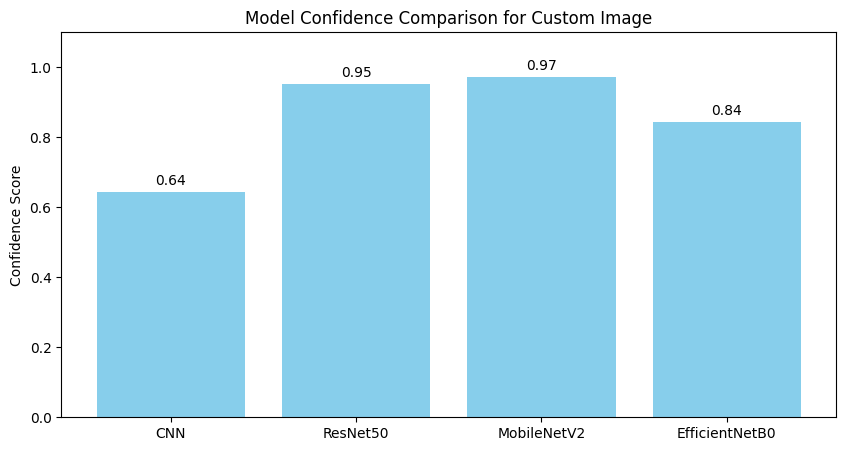

In [ ]:
if custom_results:
    names = list(custom_results.keys())
    confs = list(custom_results.values())

    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, confs, color='skyblue')
    plt.ylim(0, 1.1)
    plt.ylabel('Confidence Score')
    plt.title('Model Confidence Comparison for Custom Image')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center')

    best_m = max(custom_results, key=custom_results.get)
    print(f"The best performing model for this specific image is: {best_m} with {custom_results[best_m]*100:.2f}% confidence.")
    plt.show()
else:
    print("Run the prediction cells above first.")